# Deep Learning for Malaria Diagnosis
This notebook is inspired by works of (Sivaramakrishnan Rajaraman  et al., 2018) and (Jason Brownlee, 2019). Acknowledge to NIH and Bangalor Hospital who make available this malaria dataset.

Malaria is an infectuous disease caused by parasites that are transmitted to people through the bites of infected female Anopheles mosquitoes.

The Malaria burden with some key figures:
<font color='red'>
* More than 219 million cases
* Over 430 000 deaths in 2017 (Mostly: children & pregnants)
* 80% in 15 countries of Africa & India
  </font>

![MalariaBurd](https://github.com/habiboulaye/ai-labs/blob/master/malaria-diagnosis/doc-images/MalariaBurden.png?raw=1)

The malaria diagnosis is performed using blood test:
* Collect patient blood smear
* Microscopic visualisation of the parasit

![MalariaDiag](https://github.com/habiboulaye/ai-labs/blob/master/malaria-diagnosis/doc-images/MalariaDiag.png?raw=1)
  
Main issues related to traditional diagnosis:
<font color='#ed7d31'>
* resource-constrained regions
* time needed and delays
* diagnosis accuracy and cost
</font>

The objective of this notebook is to apply modern deep learning techniques to perform medical image analysis for malaria diagnosis.

*This notebook is inspired by works of (Sivaramakrishnan Rajaraman  et al., 2018), (Adrian Rosebrock, 2018) and (Jason Brownlee, 2019)*

In [ ]:
!pip install tensorboard

  Using cached tensorboard-2.21.0-py3-none-any.whl.metadata (1.8 kB)
  Using cached tensorboard_data_server-0.7.2-py3-none-manylinux_2_31_x86_64.whl.metadata (1.1 kB)
Using cached tensorboard-2.21.0-py3-none-any.whl (5.5 MB)
Using cached tensorboard_data_server-0.7.2-py3-none-manylinux_2_31_x86_64.whl (6.6 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [tensorboard] [tensorboard]


## 1. Imports

In [1]:
import os, sys, glob, json, shutil, zipfile, urllib.request
from types import SimpleNamespace

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.layers import Conv2D, ReLU, Add
from tensorboard.plugins.hparams import api as hp
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator

from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score, f1_score, roc_auc_score,
                             confusion_matrix, roc_curve, ConfusionMatrixDisplay)

print('TensorFlow', tf.__version__)

TensorFlow 2.21.0


## 2. Environment and configuration
The same notebook runs on **Google Colab** and **Kaggle**. This cell detects the platform and sets every path:

| | Colab | Kaggle |
|---|---|---|
| Images | `/content/cell_images` (downloaded from NIH if missing) | an attached dataset if present, otherwise downloaded from NIH to `/tmp` (Internet must be on) |
| Logs, checkpoints, results, split | Google Drive `MyDrive/malaria-diagnosis/` | `/kaggle/working/malaria-diagnosis/` (Output tab) |

On Kaggle, upload `split_80_10_10.csv` and `custom_resnet_results.csv` from Drive as a dataset input so the split and earlier runs are identical.

`RETRAIN_COMPLETED = False` makes re-running the notebook safe: experiments already in the results table are not retrained.

Detect running Environment

In [ ]:
SEED = 42
IMG_SIZE = (128, 128)
# 0 = uninfected (negative), 1 = parasitized (positive)
class_names = ['Uninfected', 'Parasitized']
   
RETRAIN_COMPLETED = False

# Detect Colab by its runtime marker
IN_COLAB = os.path.exists('/var/colab/hostname') or 'COLAB_RELEASE_TAG' in os.environ
IN_KAGGLE = not IN_COLAB and ('KAGGLE_KERNEL_RUN_TYPE' in os.environ or os.path.isdir('/kaggle/working'))
PLATFORM = 'colab' if IN_COLAB else 'kaggle' if IN_KAGGLE else 'local'

if IN_COLAB:
  from google.colab import drive
  drive.mount('/content/drive')
  PROJECT_DIR = '/content/drive/MyDrive/malaria-diagnosis'
  DATA_SEARCH = '/content/cell_images'
  DOWNLOAD_TO = '/content'
elif IN_KAGGLE:
  PROJECT_DIR = '/kaggle/working/malaria-diagnosis'
  DATA_SEARCH = '/kaggle/input'
  DOWNLOAD_TO = '/tmp'
else:
  PROJECT_DIR = os.path.abspath('malaria-diagnosis')
  DATA_SEARCH = os.path.abspath('cell_images')
  DOWNLOAD_TO = os.path.abspath('.')

LOG_ROOT = os.path.join(PROJECT_DIR, 'logs', 'fit')
CKPT_ROOT = os.path.join(PROJECT_DIR, 'checkpoints')
RESULTS_CSV = os.path.join(PROJECT_DIR, 'custom_resnet_results.csv')
SPLIT_CSV = os.path.join(PROJECT_DIR, 'split_80_10_10.csv')
os.makedirs(LOG_ROOT, exist_ok=True)
os.makedirs(CKPT_ROOT, exist_ok=True)

# Kaggle inputs are read-only: copy the shared split and earlier results into the working folder
if IN_KAGGLE:
  for name in ('split_80_10_10.csv', 'custom_resnet_results.csv'):
    found = glob.glob(f'/kaggle/input/**/{name}', recursive=True)
    if found and not os.path.exists(os.path.join(PROJECT_DIR, name)):
      shutil.copy(found[0], os.path.join(PROJECT_DIR, name))
      print('Copied from input:', found[0])

gpus = tf.config.list_physical_devices('GPU')
GPU_NAME = tf.config.experimental.get_device_details(gpus[0]).get('device_name', 'gpu') if gpus else 'cpu'
HARDWARE = f'{PLATFORM}_{GPU_NAME}'.replace(' ', '_')
print('Platform:', PLATFORM, '| Hardware:', HARDWARE)
print('Project folder:', PROJECT_DIR)
if not gpus:
  print('WARNING: no GPU - training will be very slow; tables, plots and Grad-CAM still work.')

Mounted at /content/drive
Platform: colab | Hardware: colab_Tesla_T4
Project folder: /content/drive/MyDrive/malaria-diagnosis


## 3. Dataset and 80/10/10 split
The NIH/NLM malaria dataset contain 27,558 cell images, 13,779 per class. The split is **stratified** (same class balance in every subset) and made on **file paths**. This prevents the same image to appear in more than one subset.

In [ ]:
def find_dataset(search_dir):
  """Locate the malaria cell-image folder under `search_dir`.

  Searches recursively for a folder that contains both a `Parasitized/` and an
  `Uninfected/` subfolder.
  Args:
    search_dir: Root directory to search

  Returns:
    Path of the folder holding `Parasitized/` and `Uninfected/`, or None if no
    such folder exists under `search_dir`.
  """
  best, best_n = None, 0
  for parasitized in glob.glob(os.path.join(search_dir, '**', 'Parasitized'), recursive=True):
    folder = os.path.dirname(parasitized)
    n = len(glob.glob(os.path.join(parasitized, '*.png')))
    if os.path.isdir(os.path.join(folder, 'Uninfected')) and n > best_n:
      best, best_n = folder, n
  if best is not None and best_n != 13779:
    print(f'Note: {best_n} Parasitized images found (expected 13,779) in {best}')
  return best

DOWNLOADED_DIR = os.path.join(DOWNLOAD_TO, 'cell_images')
cell_images_dir = find_dataset(DATA_SEARCH) or find_dataset(DOWNLOADED_DIR)
if cell_images_dir is None:
  print('Dataset not found - downloading from NIH (~340 MB)...')
  zip_path = os.path.join(DOWNLOAD_TO, 'cell_images.zip')
  try:
    urllib.request.urlretrieve('https://data.lhncbc.nlm.nih.gov/public/Malaria/cell_images.zip', zip_path)
  except OSError as e:
    raise RuntimeError('Download failed. On Kaggle, turn Internet on (Settings > Internet) '
                       'or attach the "cell images for detecting malaria" dataset.') from e
  with zipfile.ZipFile(zip_path) as z:
    z.extractall(DOWNLOAD_TO)
  os.remove(zip_path)
  cell_images_dir = find_dataset(DOWNLOADED_DIR)
print('Images:', cell_images_dir)

if os.path.exists(SPLIT_CSV):
  split_df = pd.read_csv(SPLIT_CSV)
  print('Split loaded from', SPLIT_CSV)
else:
  # sorted() so the file order - and therefore the split - is identical on every machine
  paths, labels = [], []
  for label, cls in enumerate(class_names):
    files = sorted(glob.glob(os.path.join(cell_images_dir, cls, '*.png')))
    paths += [os.path.relpath(f, cell_images_dir) for f in files]
    labels += [label] * len(files)
  paths, labels = np.array(paths), np.array(labels)

  train_val_p, test_p, train_val_y, test_y = train_test_split(
      paths, labels, test_size=0.10, stratify=labels, random_state=SEED)
  train_p, val_p, train_y, val_y = train_test_split(
      train_val_p, train_val_y, test_size=0.10 / 0.90, stratify=train_val_y, random_state=SEED)

  split_df = pd.DataFrame({
      'path': np.concatenate([train_p, val_p, test_p]),
      'label': np.concatenate([train_y, val_y, test_y]),
      'split': ['train'] * len(train_p) + ['val'] * len(val_p) + ['test'] * len(test_p),
      })
  split_df.to_csv(SPLIT_CSV, index=False)
  print('Split created and saved to', SPLIT_CSV)

def get_split(name):
  """
  This function split the images into training, validation and testing set
  The 80/10/10 split is used once and save inside split_80_10_10.csv
  Args:
    name: Subset to return:train, val, test
  return Tuple of (path, labels) 
  """
  part = split_df[split_df.split == name]
  return np.array([os.path.join(cell_images_dir, p) for p in part.path]), part.label.values.astype(int)

train_p, train_y = get_split('train')
val_p, val_y = get_split('val')
test_p, test_y = get_split('test')
assert all(os.path.exists(p) for p in test_p[:20]), 'split paths do not match the dataset folder'
for name, y in (('train', train_y), ('val', val_y), ('test', test_y)):
  print(f'{name}: {len(y)} images ({int(y.sum())} parasitized)')

Dataset not found - downloading from NIH (~340 MB)...
Images: /tmp/cell_images
Split created and saved to /kaggle/working/malaria-diagnosis/split_80_10_10.csv
train: 22046 images (11023 parasitized)
val: 2756 images (1378 parasitized)
test: 2756 images (1378 parasitized)


## 4. Model: Custom ResNet (Keras Subclassing API)

In [ ]:
class ResidualBlock(layers.Layer):
  """
  Residual block of the Custom Resnet

  Main path: Conv3x3(strid) then BatchNorm then Relu then Conv3x3 then BatchNorm
  Shortcut: Identity or 1x1 Conv follow by BatchNorm projection when the block changes
            the spatial size (stride different of 1) or the channel count
  output: ReLU (main path and shortcut)
  Args:
    filters:int: Number of output channels of both 3x3 convulations (and of the projection if used)
    stride:int:Stride of the first convulation and of the projection. 2 halves the height and width
    l2:float Ridge weight=decay factor applied to every convulational kernel in the block
        default to 0 to disables it
    **kwargs: passed to 'keras.layers.Layer 
  """
  def __init__(self,
               filters:int,
               stride:int=1,
               l2:float=0.0,
               **kwargs
               ):
    super().__init__(**kwargs)
    self.filters, self.stride = filters, stride
    
    self.regularizer = keras.regularizers.l2(l2) if l2 > 0 else None

    self.conv1 = Conv2D(
        filters=filters,
        kernel_size=3,
        strides=stride,
        padding="same",
        use_bias=False,
        kernel_regularizer=self.regularizer
        )
    self.batch_normalization1 = layers.BatchNormalization()
    self.conv2 = Conv2D(
        filters=filters,
        kernel_size=3,
        strides=1,
        padding="same",
        use_bias=False,
        kernel_regularizer=self.regularizer
        )
    self.batch_normalization2 = layers.BatchNormalization()

    self.relu = ReLU()
    self.add = Add()

    self.project_conv = None
    self.project_batchNn = None

  def build(self, input_shape) -> None:
    """
    This function implement a projection shortcut 
    when spatial size or channel count changes
    input_shape: (batch, height, width, channel)
    return None
    """
    if self.stride != 1 or input_shape[-1] != self.filters:
      self.project_conv = Conv2D(
          filters = self.filters,
          strides=self.stride,
          kernel_size=1,
          padding="same",
          use_bias=False,
          kernel_regularizer=self.regularizer
          )
      self.project_batchNn = layers.BatchNormalization()
    super().build(input_shape)

  def call(self, x, training=None):
    """
    Forward pass: Conv-BN-ReLU-Conv-BN,
    add the shortcut, then ReLU
    Args:
      x:shortcut value
      training:set default to None
    return self.relu()
    """
    shortcut = x
    if self.project_conv is not None:
      shortcut = self.project_batchNn(
          self.project_conv(x),
          training=training
          )
    y = self.relu(
        self.batch_normalization1(self.conv1(x), training=training)
        )
    y = self.batch_normalization2(self.conv2(y), training=training)
    return self.relu(self.add([y, shortcut]))


class CustomResNet(keras.Model):
  """Custom ResNet for binary malaria cell classification (Keras Subclassing API).

  Stem (Conv3x3-BN-ReLU) 4 stages of 2 ResidualBlocks (32, 64, 128, 256 filters;
  stages 2-4 halve the size with a projection shortcut) -> GlobalAvgPool -> Dropout
  -> Dense(1) logit -> sigmoid. With defaults: 128x128x3 input, 16x16x256 final
  feature map, about 2.8M parameters.

  The logit and the last feature map are exposed via `call(..., return_features=True)`
  for Grad-CAM.

  Args:
    stage_filters: Output channels per stage; its length sets the number of stages.
    dropout: Dropout rate before the classifier.
    block_per_stage: ResidualBlocks per stage.
    l2: L2 weight decay on all kernels (0 = off).
    stem_stride: 1 keeps 128x128 in stage 1; 2 halves it (about 4x less compute).
    **kwargs: Passed to `keras.Model`.
  """
  def __init__(self,
               stage_filters=(32, 64, 128, 256),
               dropout=0.0,
               block_per_stage:int=2,
               l2:float=0.0,
               stem_stride:int=1,
               **kwargs
               ):
    super().__init__(**kwargs)

    self.rescale = layers.Rescaling(1/255)

    self.block_per_stage = block_per_stage
    self.regularizer = keras.regularizers.l2(l2) if l2 > 0 else None

    # first step conv-batch-relu
    self.stem_conv = Conv2D(
        filters=stage_filters[0],
        kernel_size=3,
        strides=stem_stride,
        padding="same",
        use_bias=False,
        kernel_regularizer=self.regularizer
    )
    self.stem_batchNormalization = layers.BatchNormalization()
    self.relu = ReLU()

    self.blocks = []
    for stage_index, filters in enumerate(stage_filters):
      for block_index in range(block_per_stage):
        stride = 2 if (stage_index > 0 and block_index == 0) else 1
        self.blocks.append(
            ResidualBlock(
                filters=filters,
                stride=stride,
                l2=l2,
                name=f"stage{stage_index + 1}_{block_index + 1}"
                )
        )

    # global average pooling
    self.global_pool = layers.GlobalAveragePooling2D()

    self.dropout = layers.Dropout(dropout)
    self.classifier = layers.Dense(1, dtype="float32", kernel_regularizer=self.regularizer)
    self.sigmoid = layers.Activation("sigmoid", dtype="float32")

  def call(self, x, training=None, return_features=False):
    """
    Forward pass. 
    Returns the probability of Parasitized (label 1).
    With return_features=True,
    returns (logit, last conv feature map) for Grad-CAM
    Args:
        x:the shortcut
        training set to None by default
        return_features set to None by default
    return self.sigmoid()
    """
    x = self.rescale(x)
    x = self.relu(
        self.stem_batchNormalization(
            self.stem_conv(x),
            training=training
            )
        )
    for block in self.blocks:
      x = block(x, training=training)

    features = x
    x = self.global_pool(features)
    x = self.dropout(x, training=training)
    logit = self.classifier(x)

    if return_features:
      return logit, features
    return self.sigmoid(logit)

In [ ]:
model = CustomResNet()
print(model(tf.zeros((1, 128, 128, 3))).shape)

logit, feats = model(tf.zeros((1, 128, 128, 3)), return_features=True)
print(logit.shape, feats.shape)

model.summary()

I0000 00:00:1791300266.935160      23 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1791300266.940150      23 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


(1, 1)
(1, 1) (1, 16, 16, 256)


Model: "custom_res_net"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (1, 128, 128, 3)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (1, 128, 128, 32)      │           864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (1, 128, 128, 32)      │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ stage1_1 (ResidualBlock)        │ ?                      │        18,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ stage1_2 (ResidualBlock)        │ ?                      │        18,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ stage2_1 (ResidualBlock)        │ ?                      │        58,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ stage2_2 (ResidualBlock)        │ ?                      │        74,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ stage3_1 (ResidualBlock)        │ ?                      │       230,912 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ stage3_2 (ResidualBlock)        │ ?                      │       295,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ stage4_1 (ResidualBlock)        │ ?                      │       920,576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ stage4_2 (ResidualBlock)        │ ?                      │     1,181,696 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ ?                      │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (1, 1)                 │           257 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ ?                      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,800,097 (10.68 MB)

 Trainable params: 2,795,297 (10.66 MB)

 Non-trainable params: 4,800 (18.75 KB)

In [ ]:
# Check the options used by later experiments: stride-2 stem and L2 on every kernel
check = CustomResNet(stem_stride=2, l2=1e-4)
logit, feats = check(tf.zeros((1, 128, 128, 3)), return_features=True)
print(feats.shape, len(check.losses))   # (1, 8, 8, 256) 21
del check

(1, 8, 8, 256) 21


## 5. Grad-CAM
Computed on the **logit** (before the sigmoid), so confident predictions do not produce empty heatmaps through sigmoid saturation.

In [ ]:
import matplotlib.pyplot as plt

def grad_cam(model,
             image,
             target_class=1
             ):
  """
  image: (128, 128, 3) array, 0-255
  target_class: 1 = explain 'Parasitized', 0 = explain 'Uninfected'
  returns: (128, 128) heatmap in [0, 1], probability of Parasitized
  """
  img = tf.convert_to_tensor(image[None, ...], dtype=tf.float32)

  with tf.GradientTape() as tape:
    logit, features = model(img, training=False, return_features=True)
    # positive logit = evidence for Parasitized; negate to explain Uninfected
    score = logit[:, 0] if target_class == 1 else -logit[:, 0]

  grads = tape.gradient(score, features)                         # (1, 16, 16, 256)
  weights = tf.reduce_mean(grads, axis=(1, 2))                   # (1, 256) channel importance
  cam = tf.reduce_sum(features * weights[:, None, None, :], axis=-1)[0]   # (16, 16)
  cam = tf.nn.relu(cam)                                          # keep positive evidence only
  cam = cam / (tf.reduce_max(cam) + 1e-8)
  cam = tf.image.resize(cam[..., None], image.shape[:2])[..., 0] # upsample to 128x128

  prob = float(tf.sigmoid(logit)[0, 0])
  return cam.numpy(), prob


def show_grad_cam(model,
                  image,
                  true_label,
                  class_names=('Uninfected', 'Parasitized')
                  ):
  """
  Plots the original image and the Grad-CAM heatmap
  for the predicted class
  Args:
    model:best performing model
    image:the selected image
    true_label:image true class
    class_names:binary option between uninfected and parasitized
  return None
  """
  _, prob = grad_cam(model, image)
  pred_label = int(prob >= 0.5)
  cam, _ = grad_cam(model, image, target_class=pred_label)

  fig, ax = plt.subplots(1, 2, figsize=(7, 3.5))
  ax[0].imshow(image.astype('uint8'))
  ax[0].set_title(f'True: {class_names[true_label]}')
  ax[1].imshow(image.astype('uint8'))
  ax[1].imshow(cam, cmap='jet', alpha=0.4)
  ax[1].set_title(f'Pred: {class_names[pred_label]} (p={prob:.2f})')
  for a in ax:
    a.axis('off')
  plt.show()

## 6. Input pipeline and augmentation
Images are decoded once and cached in RAM. Training data is shuffled every epoch, then batched, then augmented, to help every epoch sees new random transforms.

Augmentation modes: `False` (none), `True` (exp 04: flips + ±90° rotation + ±10% zoom, black fill), `'lossless'` (flips + transpose: the 8 orientations of the cell, no pixel resampling).

In [ ]:
AUTOTUNE = tf.data.AUTOTUNE

def load_image(path, label):
  """
  This function loads the image then resize the image
  Args:
    path:path to the image
    label:correct label of the image
  return tf.cast()
  """
  img = tf.io.decode_png(tf.io.read_file(path), channels=3)
  img = tf.image.resize(img, IMG_SIZE)
  return tf.cast(tf.round(img), tf.uint8), tf.cast(label, tf.float32)

# Decode once and keep in RAM to enable later epochs and experiments skip disk reads
train_base = tf.data.Dataset.from_tensor_slices((train_p, train_y)).map(load_image, AUTOTUNE).cache()
val_base   = tf.data.Dataset.from_tensor_slices((val_p, val_y)).map(load_image, AUTOTUNE).cache()
test_base  = tf.data.Dataset.from_tensor_slices((test_p, test_y)).map(load_image, AUTOTUNE).cache()

AUG_DESCS = {
    'full': 'flip_hv + rotation_0.25 + zoom_0.1 (constant black fill)',
    'lossless': 'flip_hv + transpose (8 lossless orientations, no interpolation)',
    }

def aug_desc(mode):
  """
  This function applies transformation
  """
  if not mode:
    return 'none'
  return AUG_DESCS['full' if mode is True else mode]


class RandomTranspose(layers.Layer):
  """
  Swaps height and width per image; with h+v flips this gives all 8 orientations
  of a square image (90° rotations + mirrors) without resampling any pixel
  """
  def call(self, x, training=None):
    if not training:
      return x
    mask = tf.random.uniform([tf.shape(x)[0], 1, 1, 1]) < 0.5
    return tf.where(mask, tf.transpose(x, [0, 2, 1, 3]), x)


def make_augmenter(mode):
  """
  mode: False (none), True / 'full' (exp 04 settings),
  'lossless' (flips + transpose)
  """
  if not mode:
    return None
  if mode == 'lossless':
    return keras.Sequential([
        layers.RandomFlip("horizontal_and_vertical"),
        RandomTranspose(),
        ])
  return keras.Sequential([
      layers.RandomFlip("horizontal_and_vertical"),
      layers.RandomRotation(0.25, fill_mode="constant", fill_value=0.0),  # black, like the slide background
      layers.RandomZoom(0.1, fill_mode="constant", fill_value=0.0),
      ])


def make_ds(base,
            batch_size,
            shuffle=False,
            augmenter=None
            ):
  """Build a batched tf.data pipeline from one of the cached base datasets.

  Args:
    base: Cached dataset of (uint8 image, label) pairs (train_base, val_base or test_base).
    batch_size: Number of images per batch.
    shuffle: Reshuffle the whole dataset every epoch (training data only).
    augmenter: Keras augmentation model from `make_augmenter`, or None for no
      augmentation (always None for validation and test data).

  Returns:
    tf.data.Dataset of (float32 image batch, label batch), values in 0-255;
    the model rescales them to 0-1.
  """

  ds = base
  if shuffle:
    ds = ds.shuffle(len(train_p), seed=SEED, reshuffle_each_iteration=True)
  ds = ds.batch(batch_size).map(lambda x, y: (tf.cast(x, tf.float32), y), AUTOTUNE)
  if augmenter is not None:
    ds = ds.map(lambda x, y: (augmenter(x, training=True), y), AUTOTUNE)
  return ds.prefetch(AUTOTUNE)

## 7. Training, evaluation and experiment tracking
`run_experiment` trains on the training set, early-stops on validation loss, evaluates on validation and test, and logs everything. Every run is appended to `custom_resnet_results.csv`.

In [ ]:
# Results table: one row per experiment, saved after every run (survives disconnects)
results = pd.read_csv(RESULTS_CSV).to_dict('records') if os.path.exists(RESULTS_CSV) else []
histories, test_probs = {}, {}
print('Runs in results table:', [r['experiment'] for r in results])

Runs in results table: []


In [ ]:
def compute_metrics(model,
                    ds,
                    y_true,
                    threshold=0.5
                    ):
  """
  This is the helper functions to compute performance after every epoch
  Args:
    model: used for the experiment
    ds:image
    y_true:true label of the image
    threshold:the decision threshold default to 0.5, raise to maximize precision over recall
  return tuple containing dict of metrics and y_prod
  """
  y_prob = model.predict(ds, verbose=0).ravel()
  y_pred = (y_prob >= threshold).astype(int)
  tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
  metrics = {
      'accuracy': accuracy_score(y_true, y_pred),
      'precision': precision_score(y_true, y_pred, zero_division=0),
      'recall_sensitivity': tp / (tp + fn),
      'specificity': tn / (tn + fp),
      'f1': f1_score(y_true, y_pred, zero_division=0),
      'roc_auc': roc_auc_score(y_true, y_prob),
      }
  return metrics, y_prob


def build_optimizer(name:str, lr:float):
  """
  This function enables user to choose and switch between optimizer function
  Args:
    name:str = optimizer function name. eg. adam
    lr:float = choosen learning rate
  return keras.optimizers
  """
  if name.lower() == 'adam':
    return keras.optimizers.Adam(lr)
  if name.lower() == 'sgd':
    return keras.optimizers.SGD(lr, momentum=0.9)
  if name.lower() == 'rmsprop':
    return keras.optimizers.RMSprop(lr)
  raise ValueError(f'Unknown optimizer: {name}')


def build_model(config):
  """
  This model wraps the Custom Resnet class to a single callable function
  Args:
    config:dict containing all model configurations setup
  return CustomResnet
  """
  return CustomResNet(
      stage_filters=config['stage_filters'],
      dropout=config['dropout'],
      block_per_stage=config['block_per_stage'],
      l2=config.get('l2', 0.0),
      stem_stride=config.get('stem_stride', 1),
      )


def run_experiment(run_name,
                   config
                   ):
  """
  Train on train, early-stop on val, then report val and test metrics.
  Logs curves, hyperparameters and final metrics to TensorBoard.
  Args:
    run_name:the name of experiment to be recorded
    config:dict containing all experiment running config
  return model, history, test_prob
  """
  config = {**config, 'hardware': config.get('hardware', HARDWARE)}
  keras.backend.clear_session()
  keras.utils.set_random_seed(SEED)

  augmenter = make_augmenter(config['augment'])
  train_ds = make_ds(train_base, config['batch_size'], shuffle=True, augmenter=augmenter)
  val_ds = make_ds(val_base, config['batch_size'])
  test_ds = make_ds(test_base, config['batch_size'])

  model = build_model(config)
  model.compile(
      optimizer=build_optimizer(config['optimizer'], config['learning_rate']),
      loss="binary_crossentropy",
      metrics=["accuracy", keras.metrics.AUC(name="auc"),
               keras.metrics.Recall(name="recall"), keras.metrics.Precision(name="precision")],
      )

  log_dir = os.path.join(LOG_ROOT, run_name)
  ckpt_path = os.path.join(CKPT_ROOT, f'{run_name}.weights.h5')
  callbacks = [
      keras.callbacks.TensorBoard(log_dir=log_dir),
      keras.callbacks.EarlyStopping(monitor='val_loss', patience=config['patience'],
                                    restore_best_weights=True),
      keras.callbacks.ModelCheckpoint(ckpt_path, monitor='val_loss',
                                      save_best_only=True, save_weights_only=True),
      ]
  if config.get('lr_schedule') == 'plateau':
    callbacks.append(keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6, verbose=1))

  history = model.fit(train_ds, validation_data=val_ds,
                      epochs=config['epochs'], callbacks=callbacks)

  # VALIDATE (use these to compare experiments) and TEST (report these)
  val_metrics, _ = compute_metrics(model, val_ds, val_y)
  test_metrics, test_prob = compute_metrics(model, test_ds, test_y)

  # Log hyperparameters + final metrics to TensorBoard (§4.2)
  hparams = {k: str(v) if isinstance(v, (list, tuple)) else v for k, v in config.items()}
  hparams['augment_settings'] = aug_desc(config['augment'])
  hparams['epochs_run'] = len(history.history['loss'])
  with tf.summary.create_file_writer(log_dir).as_default():
    hp.hparams(hparams, trial_id=run_name)
    tf.summary.text('config', json.dumps(hparams), step=0)
    for split, metrics in (('val', val_metrics), ('test', test_metrics)):
      for k, v in metrics.items():
        tf.summary.scalar(f'final_{split}/{k}', v, step=0)

  # Record the row and save it
  row = {'experiment': run_name, **hparams,
         **{f'val_{k}': round(v, 4) for k, v in val_metrics.items()},
         **{f'test_{k}': round(v, 4) for k, v in test_metrics.items()}}
  results[:] = [r for r in results if r['experiment'] != run_name] + [row]
  pd.DataFrame(results).to_csv(RESULTS_CSV, index=False)
  histories[run_name] = history.history
  test_probs[run_name] = test_prob

  sens, spec = test_metrics['recall_sensitivity'], test_metrics['specificity']
  print(f"\n{run_name}  |  VAL  sens={val_metrics['recall_sensitivity']:.4f} "
        f"spec={val_metrics['specificity']:.4f}  |  TEST sens={sens:.4f} spec={spec:.4f} "
        f"AUC={test_metrics['roc_auc']:.4f}  |  target (90/90) met: {sens >= 0.9 and spec >= 0.9}")
  return model, history, test_prob


def plot_final(history,
               y_true,
               y_prob,
               run_name,
               threshold=0.5):
  """
  This function plots accuracy, loss, confusion matrix, ROC - in one row
  Args:
    history
    y_true:correct label
    y_prob:probability of an image to be in x class
    run_name:experiment name
    threshold:set threshold to 0.5 by default
  return None
  """
  h = history.history
  epochs = range(1, len(h['loss']) + 1)
  fig, ax = plt.subplots(1, 4, figsize=(22, 4.5))

  ax[0].plot(epochs, h['accuracy'], label='train'); ax[0].plot(epochs, h['val_accuracy'], label='val')
  ax[0].set(title='Accuracy', xlabel='Epoch', ylabel='Accuracy'); ax[0].legend()

  ax[1].plot(epochs, h['loss'], label='train'); ax[1].plot(epochs, h['val_loss'], label='val')
  ax[1].set(title='Loss', xlabel='Epoch', ylabel='Binary cross-entropy'); ax[1].legend()

  y_pred = (y_prob >= threshold).astype(int)
  ConfusionMatrixDisplay(confusion_matrix(y_true, y_pred),
                         display_labels=class_names).plot(ax=ax[2], colorbar=False, cmap='Blues')
  ax[2].set_title('Confusion matrix (test)')

  fpr, tpr, _ = roc_curve(y_true, y_prob)
  ax[3].plot(fpr, tpr, label=f'AUC = {roc_auc_score(y_true, y_prob):.4f}')
  ax[3].plot([0, 1], [0, 1], 'k--', linewidth=0.8)
  ax[3].set(title='ROC curve (test)', xlabel='False positive rate (1 - specificity)',
            ylabel='True positive rate (sensitivity)'); ax[3].legend(loc='lower right')

  fig.suptitle(run_name); plt.tight_layout(); plt.show()

## 8. Helpers: re-running safely, results table, error analysis
- `run_and_plot` trains a run **only if it is not already in the results table**. For finished runs it rebuilds the plots from the saved checkpoint and TensorBoard logs instead (no training), or skips if those files are not available on this platform.
- `keep_if_better` applies the selection rule fixed before running exp 05-07: **a change is kept only if validation ROC-AUC improves**.

In [ ]:
def history_from_tensorboard(run_name):
  """
  Rebuilds history.history (train and validation curves) from the TensorBoard logs
  Args:
    run_name:str = Name of experiment
  return SimpleNamespace(history)
  """
  hist = {}
  for split, prefix in (('train', ''), ('validation', 'val_')):
    ea = EventAccumulator(os.path.join(LOG_ROOT, run_name, split),
                          size_guidance={'tensors': 0, 'scalars': 0})
    ea.Reload()
    for tag in ea.Tags()['tensors'] + ea.Tags()['scalars']:
      if not tag.startswith('epoch_'):
        continue
      if tag in ea.Tags()['tensors']:
        by_step = {e.step: float(tf.make_ndarray(e.tensor_proto)) for e in ea.Tensors(tag)}
      else:
        by_step = {e.step: e.value for e in ea.Scalars(tag)}
      hist[prefix + tag[len('epoch_'):]] = [by_step[s] for s in sorted(by_step)]
  return SimpleNamespace(history=hist)


def load_run(run_name,
             config
             ):
  """
  Rebuilds a trained model from its best checkpoint and
  recomputes its test probabilities
  Args:
    run_name:str
    config:dict[str, any]
  return model, probs
  """
  model = build_model(config)
  model(tf.zeros((1, *IMG_SIZE, 3)))
  model.load_weights(os.path.join(CKPT_ROOT, f'{run_name}.weights.h5'))
  _, probs = compute_metrics(model, make_ds(test_base, 64), test_y)
  return model, probs


def run_and_plot(run_name,
                 config
                 ):
  """
  Train and plot,
  unless the run is already finished 
  (then rebuild plots without training)
  Args:
    run_name:str
    config:dict[str, Any]
  return (tuple[CustomResNet, SimpleNamespace])"""
  done = any(r['experiment'] == run_name for r in results)
  if done and not RETRAIN_COMPLETED:
    ckpt = os.path.join(CKPT_ROOT, f'{run_name}.weights.h5')
    if os.path.exists(ckpt) and os.path.isdir(os.path.join(LOG_ROOT, run_name, 'train')):
      print(f'{run_name}: already trained - rebuilding plots from checkpoint + TensorBoard logs (no training)')
      model, test_prob = load_run(run_name, config)
      history = history_from_tensorboard(run_name)
      plot_final(history, test_y, test_prob, run_name)
      return model, history, test_prob
    print(f'{run_name}: already in the results table - skipped (checkpoint/logs not available here)')
    return None, None, None
  model, history, test_prob = run_experiment(run_name, config)
  plot_final(history, test_y, test_prob, run_name)
  return model, history, test_prob


def diagnose_fit(history):
  """
  Train vs validation at the best epoch (lowest val_loss)
  Args:
    history
  return None"""
  if history is None:
    return
  h = history.history
  best = int(np.argmin(h['val_loss']))
  print(f"Best epoch: {best + 1}/{len(h['loss'])}")
  print(f"Train acc {h['accuracy'][best]:.4f} | val acc {h['val_accuracy'][best]:.4f} "
        f"| gap {h['accuracy'][best] - h['val_accuracy'][best]:+.4f}")
  print(f"Train loss {h['loss'][best]:.4f} | val loss {h['val_loss'][best]:.4f}")


def keep_if_better(cand_name,
                   cand_cfg,
                   cur_name,
                   cur_cfg
                   ):
  """
  Pre-specified rule: keep the change only if validation ROC-AUC improves
  Args:
    cand_name = candidate name
    cand_cfg = candidate configuration
    cur_name
    cur_cfg current config
  return keep current candidate else update
  """
  rows = {r['experiment']: r for r in results}
  c, b = rows[cand_name]['val_roc_auc'], rows[cur_name]['val_roc_auc']
  keep = c > b
  print(f"\n>>> {cand_name}: val AUC {c:.4f} vs {cur_name} {b:.4f} -> {'KEEP' if keep else 'DISCARD'}\n")
  return (cand_name, cand_cfg) if keep else (cur_name, cur_cfg)


def show_results(split='test'):
  """
  One row per experiment: what changed and resulting metrics.
  split='val' to compare runs, 'test' for the report
  """
  config_cols = ['learning_rate', 'optimizer', 'batch_size', 'dropout', 'l2', 'augment_settings',
                 'lr_schedule', 'stage_filters', 'block_per_stage', 'stem_stride', 'epochs_run', 'hardware']
  metric_cols = [f'{split}_{m}' for m in
                 ['accuracy', 'precision', 'recall_sensitivity', 'specificity', 'f1', 'roc_auc']]
  table = pd.DataFrame(results).set_index('experiment').reindex(columns=config_cols + metric_cols)
  return (table.style
          .format(precision=4, subset=metric_cols)
          .highlight_max(subset=metric_cols, color='lightgreen'))


def get_examples(y_true,
                 y_prob,
                 threshold=0.5
                 ):
  """
  Test-set indices for each outcome, most confident first
  Args:
    y_true = true label
    y_prob = probability for true
    threshold = 0.5 as default
  """
  pred = (y_prob >= threshold).astype(int)
  conf = np.abs(y_prob - 0.5)
  def most_confident(mask):
    idx = np.where(mask)[0]
    return idx[np.argsort(-conf[idx])]
  return {
      'Correct infected':   most_confident((y_true == 1) & (pred == 1)),
      'Correct uninfected': most_confident((y_true == 0) & (pred == 0)),
      'False negative':     most_confident((y_true == 1) & (pred == 0)),   # missed infection
      'False positive':     most_confident((y_true == 0) & (pred == 1)),
      }


def show_errors(y_prob,
                n=6
                ):
  """
  This function shows The most confident misclassifications
  (half false negatives, half false positives)
  """
  ex = get_examples(test_y, y_prob)
  print(f"False negatives: {len(ex['False negative'])}   False positives: {len(ex['False positive'])}")
  idx = np.concatenate([ex['False negative'][:n // 2], ex['False positive'][:n // 2]])
  if len(idx) == 0:
    print('No misclassified test images.')
    return
  fig, ax = plt.subplots(1, len(idx), figsize=(3 * len(idx), 3.6))
  for a, i in zip(np.atleast_1d(ax), idx):
    img, _ = load_image(test_p[i], test_y[i])
    a.imshow(img.numpy())
    a.set_title(f"True: {class_names[test_y[i]]}\nPred: {class_names[int(y_prob[i] >= 0.5)]}"
                f"\np(parasitized) = {y_prob[i]:.3f}", fontsize=9)
    a.axis('off')
  plt.tight_layout(); plt.show()


def show_grad_cam_cases(model,
                        y_prob,
                        run_name,
                        rank=0
                        ):
  """
  This function displays Grad-CAM for a correct infected, 
  a correct uninfected, and both error types
  Args:
    model model name
    y_prob probability of being in label
    run_name current experiment name
    rank
  return """
  cases = get_examples(test_y, y_prob)
  fig, ax = plt.subplots(2, 4, figsize=(16, 8))
  for col, (case, idx) in enumerate(cases.items()):
    ax[0, col].axis('off'); ax[1, col].axis('off')
    if len(idx) <= rank:
      ax[0, col].set_title(f'{case}\n(none)')
      continue
    i = idx[rank]
    img, _ = load_image(test_p[i], test_y[i])
    img = img.numpy()
    pred = int(y_prob[i] >= 0.5)
    cam, _ = grad_cam(model, img.astype('float32'), target_class=pred)   # explain the predicted class
    ax[0, col].imshow(img)
    ax[0, col].set_title(f'{case}\nTrue: {class_names[test_y[i]]}  |  Pred: {class_names[pred]}\n'
                         f'p(parasitized) = {y_prob[i]:.3f}', fontsize=10)
    ax[1, col].imshow(img)
    ax[1, col].imshow(cam, cmap='jet', alpha=0.4)
    ax[1, col].set_title(f'Grad-CAM for "{class_names[pred]}"', fontsize=10)
  fig.suptitle(f'Grad-CAM - {run_name}', fontsize=13)
  plt.tight_layout(); plt.show()

## 9. Experiments
Each experiment changes **one thing** relative to the best configuration so far. Experiments are compared on **validation** metrics; test metrics are reported in the results table.

In [ ]:
# Initial configuration for the model
BASE_CONFIG = dict(
    model='custom_resnet',
    stage_filters=(32, 64, 128, 256),
    block_per_stage=2,
    dropout=0.0,
    optimizer='adam',
    learning_rate=1e-3,
    batch_size=32,
    epochs=30,
    patience=5,
    augment=False,
    l2=0.0,
    lr_schedule='none',
    transfer_learning='none (trained from scratch)',
    stem_stride=1,
    )

### Experiment 01 — custom_resnet_exp_01_baseline
**Configuration:** This is a small baseline custom resnet model built with 4 stages and 2 basic blocks with half the usual width (32) (He et al., 2016). The model configuration produces around 2.8M parameters, which is enough training capacity for tis task. The resolution is kept to 128x128 in stage 1. Dropout and learning rate schedule has been set to false. The optimizer is set to Adam 

**Why this baseline:** The task only has +22K training images and small cells, a deep custom resnet with a lot of parameters will likely overfit.

Epoch 1/30


2026-10-06 15:25:03.355880: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-10-06 15:25:03.510904: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-10-06 15:25:04.528149: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-10-06 15:25:04.699185: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-10-06 15:25:05.985955: E external/local_xla/xla/stream_

688/689 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step - accuracy: 0.9090 - auc: 0.9520 - loss: 0.2584 - precision: 0.9441 - recall: 0.8636

2026-10-06 15:27:07.580015: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-10-06 15:27:07.736184: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-10-06 15:27:08.810716: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-10-06 15:27:08.984337: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-10-06 15:27:10.147381: E external/local_xla/xla/stream_

689/689 ━━━━━━━━━━━━━━━━━━━━ 170s 193ms/step - accuracy: 0.9392 - auc: 0.9760 - loss: 0.1838 - precision: 0.9662 - recall: 0.9103 - val_accuracy: 0.6390 - val_auc: 0.8815 - val_loss: 0.9740 - val_precision: 0.9948 - val_recall: 0.2794
Epoch 2/30
689/689 ━━━━━━━━━━━━━━━━━━━━ 116s 169ms/step - accuracy: 0.9533 - auc: 0.9829 - loss: 0.1481 - precision: 0.9713 - recall: 0.9341 - val_accuracy: 0.9445 - val_auc: 0.9844 - val_loss: 0.1798 - val_precision: 0.9834 - val_recall: 0.9042
Epoch 3/30
689/689 ━━━━━━━━━━━━━━━━━━━━ 116s 168ms/step - accuracy: 0.9554 - auc: 0.9854 - loss: 0.1381 - precision: 0.9729 - recall: 0.9369 - val_accuracy: 0.9594 - val_auc: 0.9903 - val_loss: 0.1240 - val_precision: 0.9759 - val_recall: 0.9419
Epoch 4/30
689/689 ━━━━━━━━━━━━━━━━━━━━ 117s 170ms/step - accuracy: 0.9566 - auc: 0.9866 - loss: 0.1323 - precision: 0.9722 - recall: 0.9401 - val_accuracy: 0.9234 - val_auc: 0.9861 - val_loss: 0.1977 - val_precision: 0.9867 - val_recall: 0.8585
Epoch 5/30
689/689 ━━━━━━━━

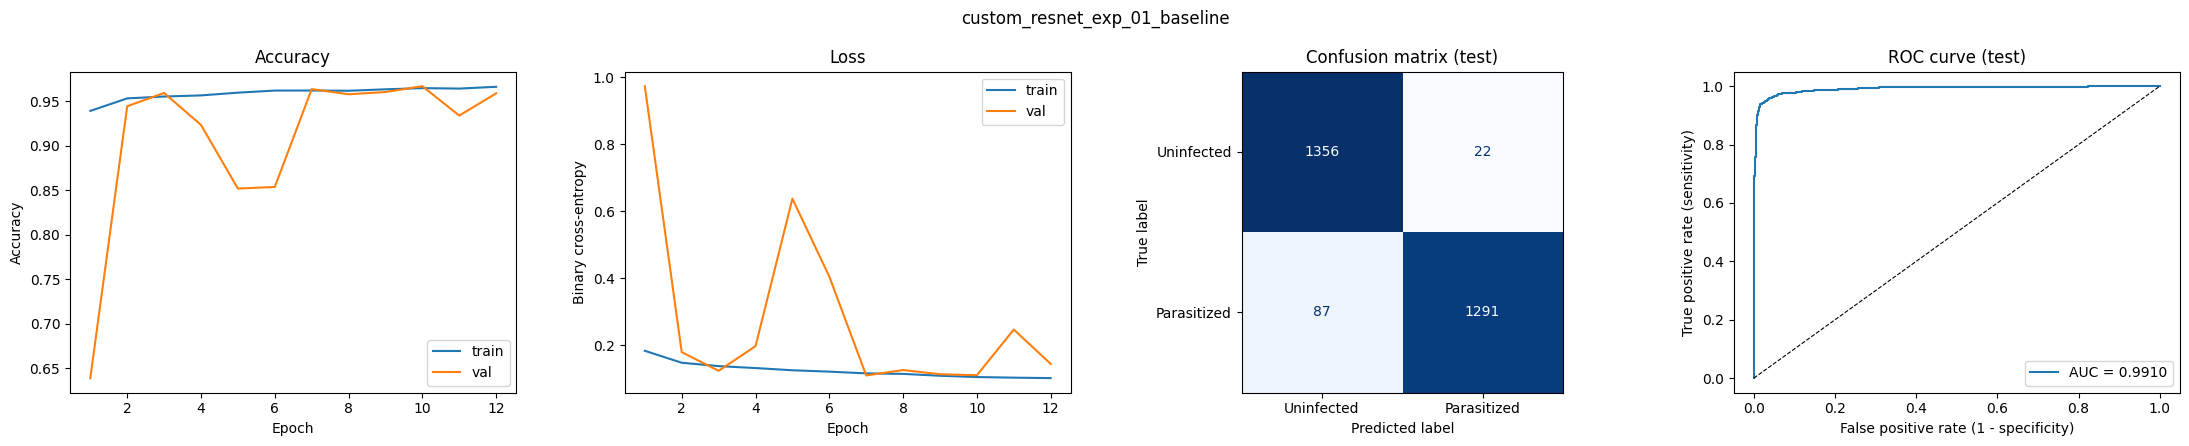

Best epoch: 7/12
Train acc 0.9621 | val acc 0.9637 | gap -0.0016
Train loss 0.1164 | val loss 0.1101


In [ ]:
model, history, test_prob = run_and_plot('custom_resnet_exp_01_baseline', BASE_CONFIG)
diagnose_fit(history)

**Result**: The validation loss in this model shows irregular instability. It decreases rapidly from epoch 1 to 3 (0.974 to 0.124), then rises between epoch 4 and 5 (up to 0.638) and decreases again from epoch 5 to 7 (down to 0.110), before stabilizing, and rises again between epoch 10 and 11 (0.111 to 0.247) then decreases. At the same time, the training loss decreases smoothly from 0.184 to 0.102 without any spike, so the model keeps learning on the training data while the validation loss jumps. This irregular behavior suggests that the learning rate used (1e-3) was too high and the model overshoots the minimum. Because of these jumps, the best validation loss was at epoch 7, and early stopping ended the training at epoch 12. The training and validation accuracy at epoch 7 are almost the same (0.962 vs 0.964), so the model is not overfitting and dropout is not expected to help. Adding ReduceLROnPlateau can help gradient descent converge better by reducing the learning rate when the validation loss stops improving.

### Experiment 02 — custom_resnet_exp_02_reduce_lr_plateau
**Change from exp 01:** ReduceLROnPlateau — halve the learning rate when val_loss has not improved for 2 epochs (min 1e-6).
**Why:** * The previous experiment shows training instability due to a large learning rate. The second experiment will introduce ReduceLROnPlateau to reduce by half the learning after two epochs if the loss has not changed 
**Expectation:** Starting with a larger learning rate might help train faster but increase the risk of missing the local minimun. Introducing the ReduceLROnPlateau will help reduce the learning rate and stabilise most of the training instability found in experiment 1
Show more
Here it is in your style, with sharper reasoning:

**Why**: The previous experiment shows instability in the validation loss (spikes at epoch 5 and 11) while the training loss decreased smoothly, which suggests that the learning rate of 1e-3 was too large once the model got close to a minimum. Because of this instability, early stopping ended the training at epoch 12 with the best epoch at 7. The second experiment will introduce ReduceLROnPlateau to reduce the learning rate by half when the validation loss has not improved for two epochs.

**Expectation**: Keeping the starting learning rate at 1e-3 should still help the model train fast in the first epochs, but a constant large learning rate increases the risk of overshooting the minimum. Reducing the learning rate when the validation loss stops improving should stabilise most of the training instability found in experiment 1. If this works, the validation loss curve should be smoother, the model should train for more epochs before early stopping, and the best validation loss and ROC-AUC should be better than in experiment 1.



Epoch 1/30
689/689 ━━━━━━━━━━━━━━━━━━━━ 146s 186ms/step - accuracy: 0.9395 - auc: 0.9762 - loss: 0.1844 - precision: 0.9661 - recall: 0.9110 - val_accuracy: 0.9604 - val_auc: 0.9892 - val_loss: 0.1293 - val_precision: 0.9669 - val_recall: 0.9536 - learning_rate: 0.0010
Epoch 2/30
689/689 ━━━━━━━━━━━━━━━━━━━━ 116s 168ms/step - accuracy: 0.9534 - auc: 0.9829 - loss: 0.1477 - precision: 0.9716 - recall: 0.9341 - val_accuracy: 0.9398 - val_auc: 0.9874 - val_loss: 0.1703 - val_precision: 0.9879 - val_recall: 0.8904 - learning_rate: 0.0010
Epoch 3/30
689/689 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step - accuracy: 0.9572 - auc: 0.9859 - loss: 0.1349 - precision: 0.9729 - recall: 0.9405
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
689/689 ━━━━━━━━━━━━━━━━━━━━ 115s 168ms/step - accuracy: 0.9560 - auc: 0.9855 - loss: 0.1374 - precision: 0.9722 - recall: 0.9389 - val_accuracy: 0.9583 - val_auc: 0.9841 - val_loss: 0.1762 - val_precision: 0.9501 - val_recall: 0.9673 - learning

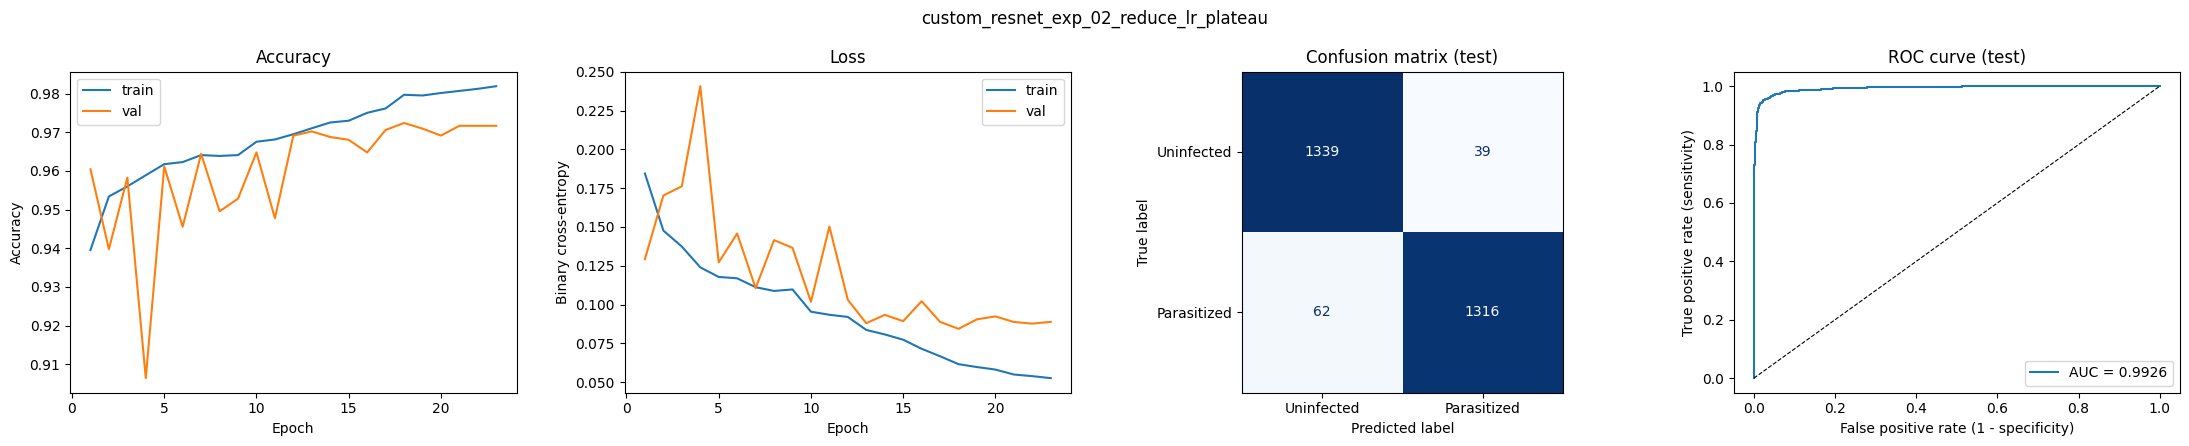

Best epoch: 18/23
Train acc 0.9797 | val acc 0.9724 | gap +0.0073
Train loss 0.0616 | val loss 0.0844


In [ ]:
CONFIG_02 = {**BASE_CONFIG, 'lr_schedule': 'plateau'}
model, history, test_prob = run_and_plot('custom_resnet_exp_02_reduce_lr_plateau', CONFIG_02)
diagnose_fit(history)

**Result:** The second experiment shows better training stability compared to the previous one. The largest validation loss spike is now 0.241 at epoch 4, compared to 0.638 in experiment 1, and the validation loss stays below 0.11 from epoch 12 onwards. As expected, the ReduceLROnPlateau halved the learning rate 7 times (from 1e-3 down to 7.8e-6), which allowed the model to take smaller steps when the validation loss stopped improving. The best epoch at 18 suggests that the model learned longer and converged better than in experiment 1 (best validation loss 0.0844 vs 0.1101, validation ROC-AUC 0.9949 vs 0.9926), as shown in the previous image. However, the model shows an early sign of overfitting: after epoch 18 the training loss keeps decreasing (0.062 to 0.053) while the validation loss stops improving (around 0.088–0.092), and the training accuracy becomes higher than the validation accuracy (0.980 vs 0.972). The early stopping therefore ended the training at epoch 23 and returned the best weights from epoch 18. On the test set, the sensitivity improved from 0.9369 to 0.9550 while the specificity decreased from 0.9840 to 0.9717.

**Decision:** Keep ReduceLROnPlateau for the next experiments. Since the model now shows an early sign of overfitting, the next experiment will test a regularization technique (dropout).

**Baseline (exp 01) vs learning-rate plateau (exp 02) - training (solid) and validation (dashed) loss**

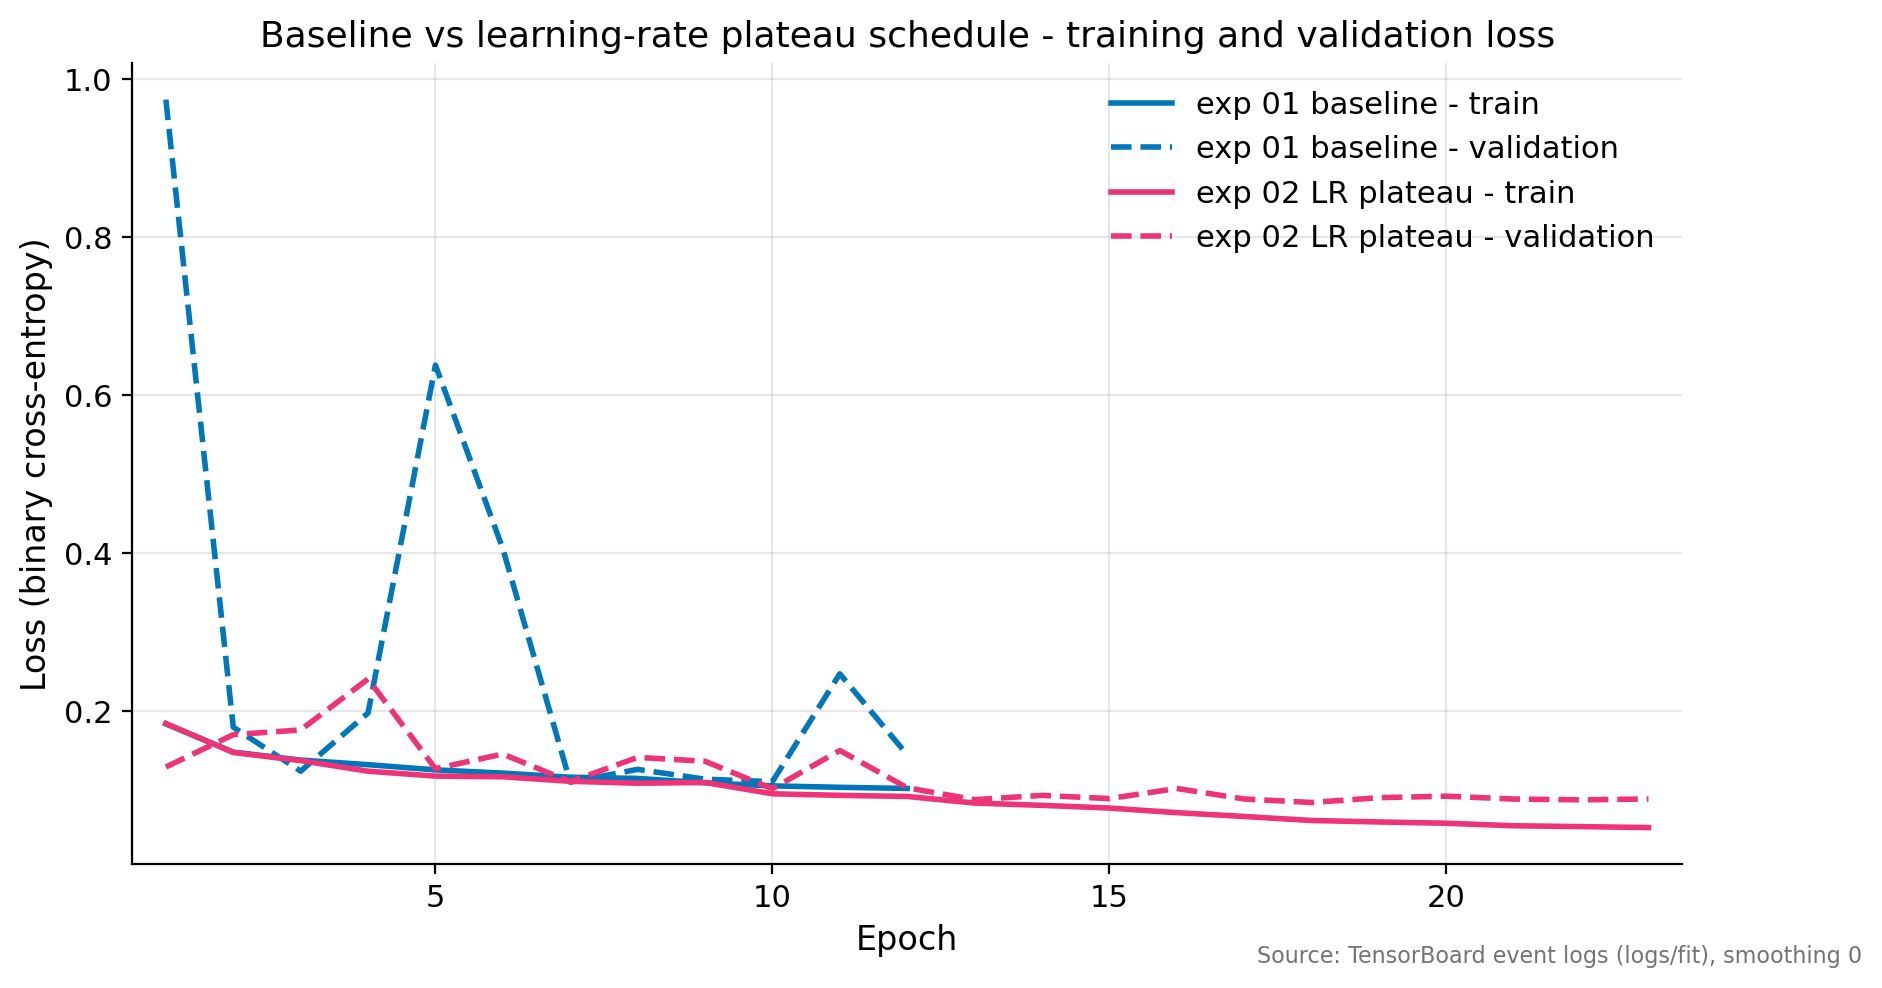

### Change from best so far (exp 02): Add regularization: introducing dropout 0.3 on the pooled features, before the classifier.

**Why:** exp 02 showed mild overfitting at its best epoch (18/23): the train/val accuracy gap is +0.73 pts (0.9797 vs 0.9724), but the gap in loss is larger (val loss 0.0844 vs train loss 0.0616), and after epoch 18 the training loss kept decreasing while the validation loss stopped improving.

**Expectation:** Dropout randomly switches off 30% of the pooled features during training, so the classifier cannot rely too much on a few features. This should reduce the gap between the training and validation loss and may help the model generalise slightly better. However, the effect is expected to be small, because dropout only acts on the final 256 pooled features and not on the convolutional layers, BatchNormalization already gives some regularization, and the overfitting in exp 02 was only mild. If dropout works, the validation loss and ROC-AUC should be equal or slightly better than exp 02, with a smaller train/val gap at the best epoch.


Epoch 1/30
689/689 ━━━━━━━━━━━━━━━━━━━━ 149s 187ms/step - accuracy: 0.9415 - auc: 0.9752 - loss: 0.1820 - precision: 0.9664 - recall: 0.9148 - val_accuracy: 0.9365 - val_auc: 0.9781 - val_loss: 0.1817 - val_precision: 0.9725 - val_recall: 0.8984 - learning_rate: 0.0010
Epoch 2/30
689/689 ━━━━━━━━━━━━━━━━━━━━ 116s 169ms/step - accuracy: 0.9541 - auc: 0.9824 - loss: 0.1480 - precision: 0.9718 - recall: 0.9353 - val_accuracy: 0.9503 - val_auc: 0.9830 - val_loss: 0.1564 - val_precision: 0.9859 - val_recall: 0.9136 - learning_rate: 0.0010
Epoch 3/30
689/689 ━━━━━━━━━━━━━━━━━━━━ 116s 168ms/step - accuracy: 0.9561 - auc: 0.9847 - loss: 0.1387 - precision: 0.9724 - recall: 0.9389 - val_accuracy: 0.9147 - val_auc: 0.9746 - val_loss: 0.3884 - val_precision: 0.8689 - val_recall: 0.9768 - learning_rate: 0.0010
Epoch 4/30
689/689 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step - accuracy: 0.9552 - auc: 0.9846 - loss: 0.1385 - precision: 0.9734 - recall: 0.9374
Epoch 4: ReduceLROnPlateau reducing learning rate t

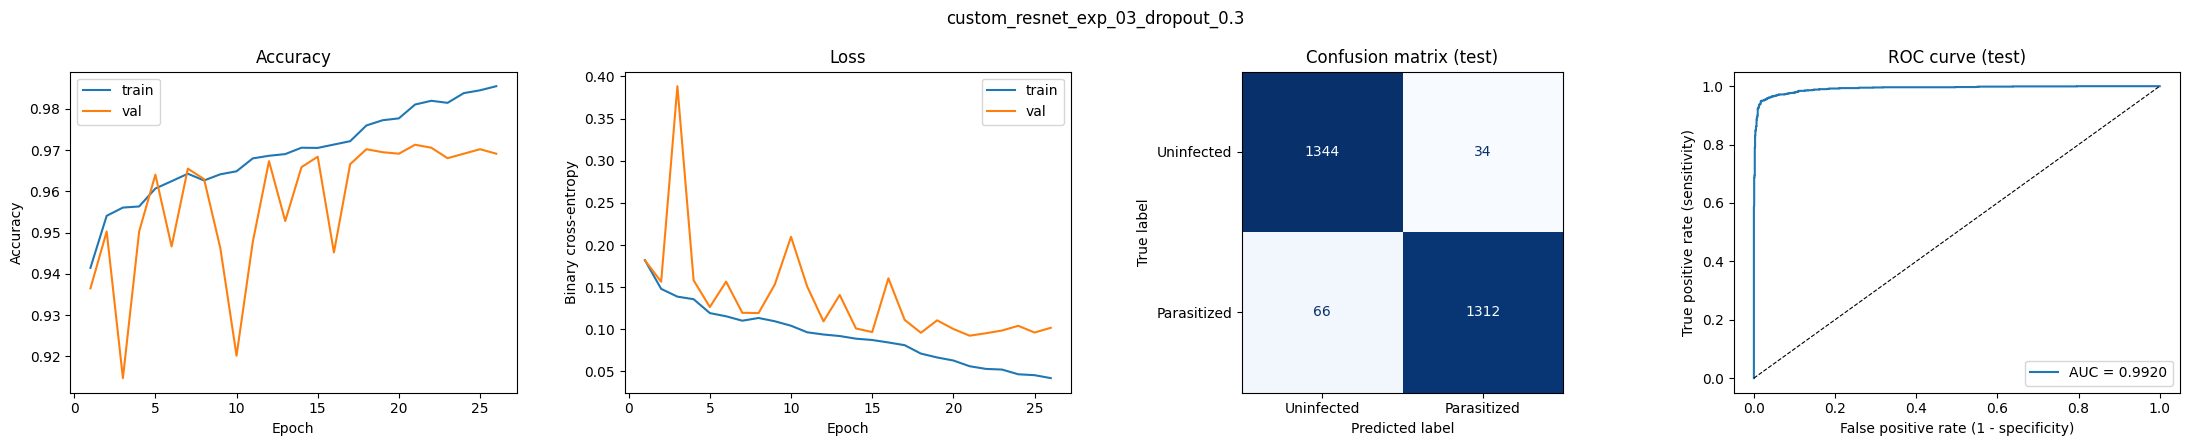

Best epoch: 21/26
Train acc 0.9811 | val acc 0.9713 | gap +0.0097
Train loss 0.0562 | val loss 0.0924


In [ ]:
CONFIG_03 = {**CONFIG_02, 'dropout': 0.3}
model, history, test_prob = run_and_plot('custom_resnet_exp_03_dropout_0.3', CONFIG_03)
diagnose_fit(history)

**Result:** Adding dropout did not improve the model. The best epoch was 21 out of 26, and at this epoch the gap between training and validation accuracy became slightly larger than in exp 02 (+0.98 pts: 0.9811 vs 0.9713, compared to +0.73 pts before), and the validation loss was higher (0.0924 vs 0.0844 in exp 02). The validation ROC-AUC also decreased slightly from 0.9949 to 0.9942. The validation sensitivity increased a little (0.9673 vs 0.9659) while the specificity decreased (0.9753 vs 0.9790), but these differences are very small and within the noise of the validation set (about ±1 point). On the test set, the results are also very close to exp 02 (sensitivity 0.9521 vs 0.9550, specificity 0.9753 vs 0.9717, ROC-AUC 0.9920 vs 0.9926). This confirms the expectation that dropout would only have a small effect: it only acts on the 256 pooled features at the end of the network, while most of the learning happens in the convolutional layers, which already have BatchNormalization.

**Decision:** Discard dropout and keep exp 02 as the best configuration. Since regularizing only the classifier did not help, the next experiment will test data augmentation, which regularizes the whole network by showing the model new variations of the training images.

### Experiment 04 — custom_resnet_exp_04_augmentation
**Change from best so far** (exp 02; exp 03's dropout was not kept): This experiment builds on exp 02 (without dropout) and introduces data augmentation on the training set with random flips (horizontal and vertical), rotation ±90°, zoom ±10% and black fill.

**Why**: Dropout at the head had no effect, and the model performed slightly worse than in the second experiment. Dropout only regularized the classifier, while most of the learning happens in the convolutional layers. Data augmentation regularizes the whole network, because the model sees a new version of each training image at every epoch. It also matches the nature of the data: a cell under the microscope has no natural orientation, so a flipped or rotated cell is still a valid example of the same class.

**Expectation:** With ReduceLROnPlateau and augmentation, we expect the gap between the training and validation loss at the best epoch to become smaller than in exp 02, because the model can no longer memorise the exact training images. The training accuracy may even be slightly lower than the validation accuracy, since the model trains on harder, transformed images. We expect the validation ROC-AUC, and metrics such as precision, sensitivity, specificity and F1, to improve compared to exp 02. One possible risk is that rotation by any angle and zoom re-sample the pixels and add black corners, so the augmented training images may look slightly different from the validation images, which could make training less stable.

Epoch 1/30
689/689 ━━━━━━━━━━━━━━━━━━━━ 147s 186ms/step - accuracy: 0.9124 - auc: 0.9618 - loss: 0.2443 - precision: 0.9370 - recall: 0.8842 - val_accuracy: 0.9550 - val_auc: 0.9830 - val_loss: 0.1644 - val_precision: 0.9511 - val_recall: 0.9594 - learning_rate: 0.0010
Epoch 2/30
689/689 ━━━━━━━━━━━━━━━━━━━━ 117s 169ms/step - accuracy: 0.9490 - auc: 0.9791 - loss: 0.1633 - precision: 0.9680 - recall: 0.9286 - val_accuracy: 0.9496 - val_auc: 0.9863 - val_loss: 0.1514 - val_precision: 0.9784 - val_recall: 0.9194 - learning_rate: 0.0010
Epoch 3/30
689/689 ━━━━━━━━━━━━━━━━━━━━ 116s 168ms/step - accuracy: 0.9518 - auc: 0.9827 - loss: 0.1493 - precision: 0.9687 - recall: 0.9339 - val_accuracy: 0.9456 - val_auc: 0.9817 - val_loss: 0.1786 - val_precision: 0.9774 - val_recall: 0.9122 - learning_rate: 0.0010
Epoch 4/30
689/689 ━━━━━━━━━━━━━━━━━━━━ 116s 168ms/step - accuracy: 0.9529 - auc: 0.9838 - loss: 0.1453 - precision: 0.9689 - recall: 0.9359 - val_accuracy: 0.9565 - val_auc: 0.9890 - val_lo

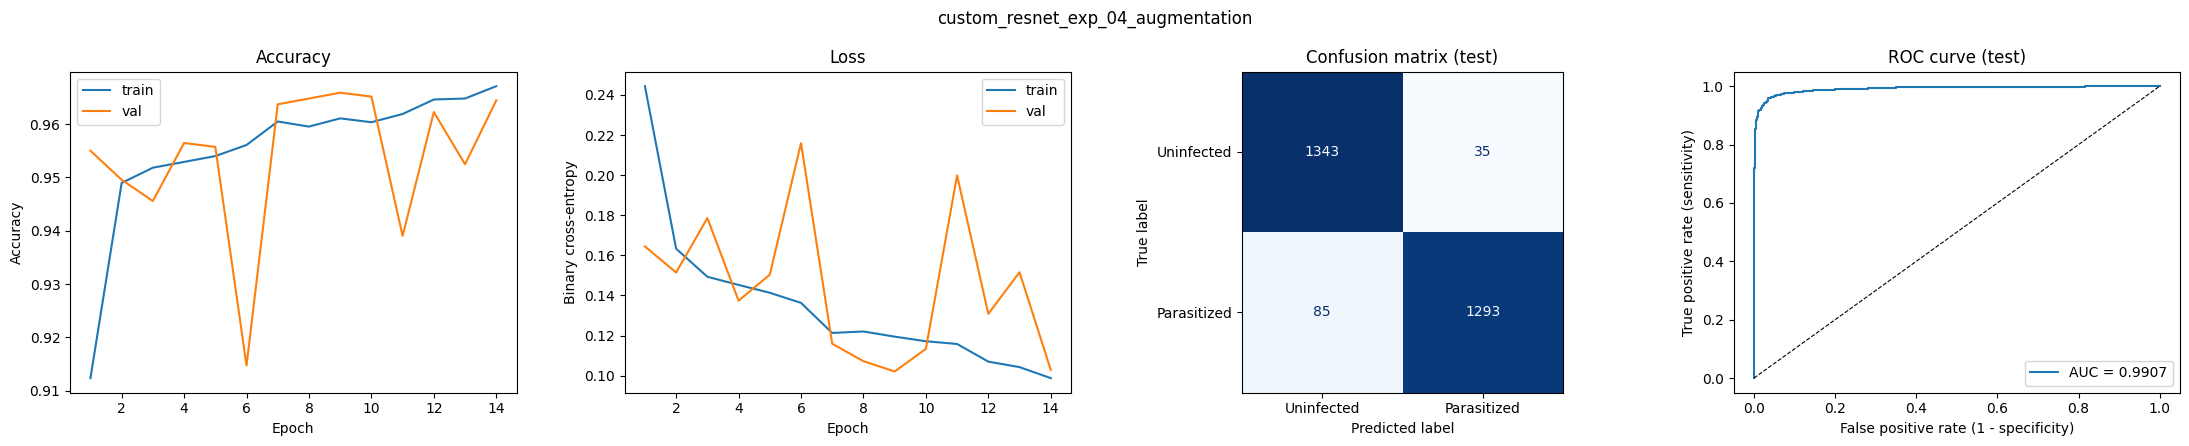

Best epoch: 9/14
Train acc 0.9611 | val acc 0.9659 | gap -0.0048
Train loss 0.1195 | val loss 0.1021


In [ ]:
CONFIG_04 = {**CONFIG_02, 'augment': True}
model, history, test_prob = run_and_plot('custom_resnet_exp_04_augmentation', CONFIG_04)
diagnose_fit(history)

**Result:** Data augmentation removed the overfitting seen in exp 02: at the best epoch (9 out of 14) the training accuracy was even slightly lower than the validation accuracy (0.9611 vs 0.9659), because the model was trained on harder, transformed images. However, the model performed worse than exp 02: the validation ROC-AUC decreased from 0.9949 to 0.9931, the best validation loss was higher (0.1021 vs 0.0844), and the validation sensitivity dropped from 0.9659 to 0.9492. The validation loss also showed two drops in performance, at epoch 6 (recall 0.837) and epoch 11 (recall 0.896), which stopped the validation loss from improving, so early stopping ended the training at epoch 14 while the training loss was still decreasing. On the test set, the sensitivity decreased from 0.9550 to 0.9383, which means more infected cells were missed. A possible explanation is that rotation by any angle and zoom re-sample the pixels, which blurs small details like the parasites, and zooming in can cut the border of the cell, where a parasite may be located. The training images therefore become different from the validation images, and some of them may lose the parasite that defines their label.

**Decision:** Not kept; the best configuration stays exp 02. Since augmentation did reduce overfitting, the next experiment will keep augmentation but use only lossless transformations (flips and 90° rotations), which change the orientation of the cell without re-sampling any pixel.

In [ ]:
# Decisions so far: exp 02 kept; exp 03 (dropout) and exp 04 (augmentation) not kept
best_name, best_config = 'custom_resnet_exp_02_reduce_lr_plateau', CONFIG_02

### Augmentation v2 (after exp 04)
**Exp 04's rotation** by any angle and zoom reduced overfitting but lowered the validation ROC-AUC and sensitivity, likely because re-sampling the pixels blurs small details and zoom can crop parasites at the cell border. A lossless option was added to the pipeline (Section 6): horizontal/vertical flips and transpose, which give the 8 orientations of the cell (90 degree rotations and mirrors) without re-sampling any pixel. The exp 04 setting is kept unchanged as augment=True.

**Selection rule for exp 05-07** (fixed before running them): a change is kept only if validation ROC-AUC improves (keep_if_better).




### Experiment 05 — custom_resnet_exp_05_augmentation_lossless
Change from best so far (exp 02): lossless augmentation — random horizontal/vertical flips + transpose, which give the 8 orientations of the cell (90° rotations and mirrors).

**Why:** The previous experiment showed that rotation by any angle and zoom reduced overfitting, but they likely blurred small details and the zoom may have cropped parasites located at the border of the cell. This made the model miss more infected cells (validation sensitivity dropped from 0.9659 in exp 02 to 0.9492). Flips and transposes only change the orientation of the cell without re-sampling any pixel, so no detail is blurred or cropped and no black corners are added. Since a cell has no natural orientation, every flipped or rotated version is still a valid image of the same class.

**Expectation:** We expect lossless augmentation to keep the benefit of exp 04, a smaller gap between training and validation than in exp 02 (+0.73 pts), while recovering the performance lost in exp 04. The validation sensitivity should go back up compared to exp 04, and the validation ROC-AUC should be equal to or higher than exp 02 (0.9949). Because the training images keep the same quality as the validation images, the training should also be more stable than in exp 04 and run for more epochs before early stopping.


Epoch 1/30
689/689 ━━━━━━━━━━━━━━━━━━━━ 141s 182ms/step - accuracy: 0.9387 - auc: 0.9752 - loss: 0.1860 - precision: 0.9647 - recall: 0.9107 - val_accuracy: 0.8995 - val_auc: 0.9840 - val_loss: 0.2392 - val_precision: 0.9885 - val_recall: 0.8084 - learning_rate: 0.0010
Epoch 2/30
689/689 ━━━━━━━━━━━━━━━━━━━━ 116s 168ms/step - accuracy: 0.9527 - auc: 0.9829 - loss: 0.1493 - precision: 0.9700 - recall: 0.9343 - val_accuracy: 0.8828 - val_auc: 0.9835 - val_loss: 0.2694 - val_precision: 0.9962 - val_recall: 0.7685 - learning_rate: 0.0010
Epoch 3/30
689/689 ━━━━━━━━━━━━━━━━━━━━ 116s 168ms/step - accuracy: 0.9550 - auc: 0.9856 - loss: 0.1389 - precision: 0.9720 - recall: 0.9371 - val_accuracy: 0.9532 - val_auc: 0.9836 - val_loss: 0.1686 - val_precision: 0.9629 - val_recall: 0.9427 - learning_rate: 0.0010
Epoch 4/30
689/689 ━━━━━━━━━━━━━━━━━━━━ 116s 168ms/step - accuracy: 0.9567 - auc: 0.9859 - loss: 0.1345 - precision: 0.9725 - recall: 0.9400 - val_accuracy: 0.9579 - val_auc: 0.9833 - val_lo

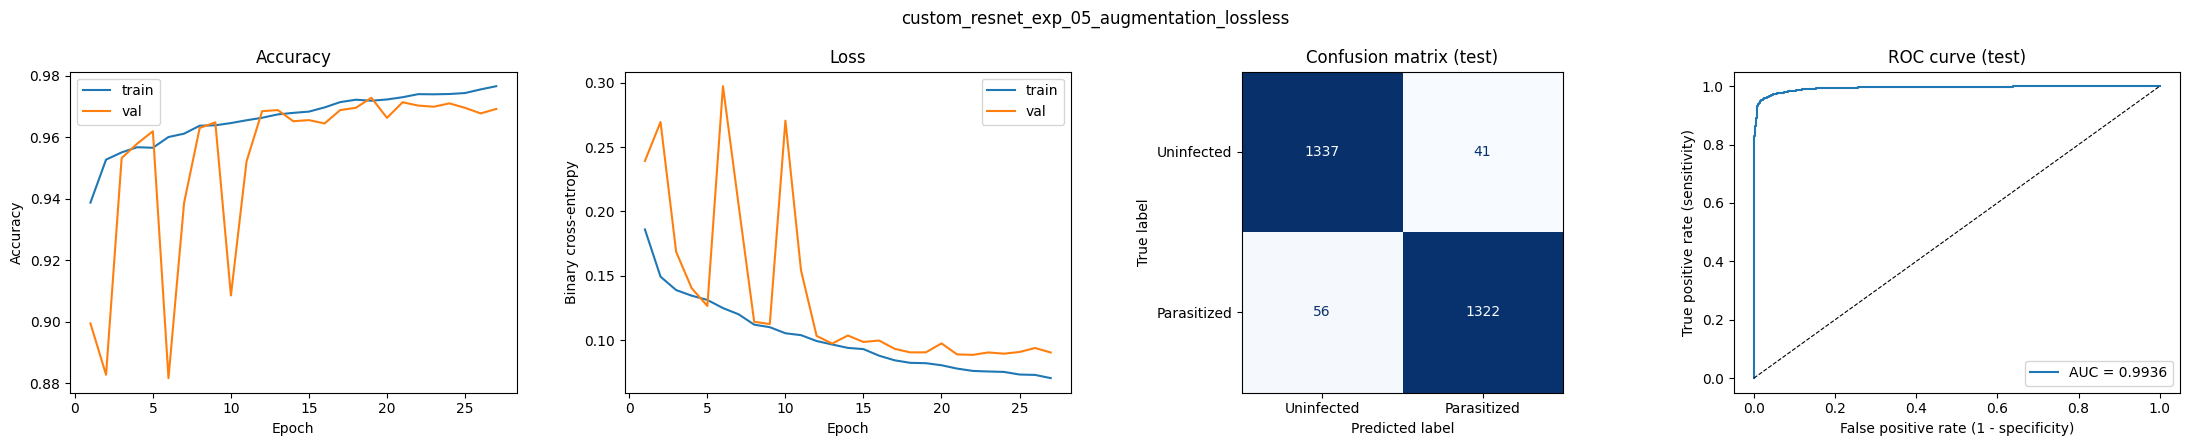

Best epoch: 22/27
Train acc 0.9740 | val acc 0.9702 | gap +0.0037
Train loss 0.0761 | val loss 0.0886

>>> custom_resnet_exp_05_augmentation_lossless: val AUC 0.9950 vs custom_resnet_exp_02_reduce_lr_plateau 0.9949 -> KEEP



In [ ]:
name = 'custom_resnet_exp_05_augmentation_lossless'
CONFIG_05 = {**best_config, 'augment': 'lossless'}
model, history, test_prob = run_and_plot(name, CONFIG_05)
diagnose_fit(history)
best_name, best_config = keep_if_better(name, CONFIG_05, best_name, best_config)

**Result:** Lossless augmentation gave the best balance so far. At the best epoch (22 out of 27), the gap between training and validation was smaller than in exp 02: the accuracy gap went from +0.73 to +0.38 pts (0.9740 vs 0.9702) and the loss gap from 0.023 to 0.013 (0.0761 vs 0.0886), so the overfitting was reduced. The model also recovered the sensitivity lost in exp 04: the validation sensitivity increased from 0.9492 to 0.9666, slightly above exp 02 (0.9659), while the validation specificity decreased a little (0.9739 vs 0.9790). The training also ran longer than exp 04 (27 epochs instead of 14). The validation loss still had some spikes in the early epochs (around 0.27–0.30 at epochs 2, 6 and 10), but it became stable after epoch 12, once the learning rate started to decrease. The validation ROC-AUC was 0.9950 against 0.9949 for exp 02, so according to the selection rule the change was kept. However, this difference is very small and within the noise of the validation set, so exp 05 and exp 02 perform almost the same. On the test set, exp 05 reached the highest sensitivity of all experiments (0.9594, with 56 missed infections out of 1,378), with a specificity of 0.9702 and a ROC-AUC of 0.9936.

**Decision:** Kept, as the selection rule decided (validation ROC-AUC 0.9950 > 0.9949). Exp 05 becomes the base for the next experiments.

### Experiment 06 — custom_resnet_exp_06_l2_1e-4
**Change from best so far (exp 05)**: L2 weight decay 1e-4 on every convolution kernel and the classifier, on top of the lossless augmentation.

**Why:** Exp 05 reduced the overfitting, but a small gap remained at the best epoch (training loss 0.0761 vs validation loss 0.0886), and after epoch 22 the training loss kept decreasing while the validation loss stopped improving. Dropout in exp 03 only regularized the classifier, and augmentation acts on the input images. L2 regularization works in a different way: it adds a penalty on the size of every weight to the loss, which pushes the network, including all convolutional layers, towards smaller and simpler weights that should generalise better.

**Expectation:** We expect L2 to reduce the remaining gap between training and validation and to keep the validation ROC-AUC equal to or slightly higher than exp 05 (0.9950). The training loss shown by Keras will be higher than before, because it now includes the L2 penalty, so the gap should be judged with accuracy and validation metrics rather than with the loss values alone. The effect may also be small: every convolution in this network is followed by BatchNormalization, which cancels the effect of the size of the weights, so with BatchNorm, L2 mostly changes how fast the weights are updated instead of limiting the model (van Laarhoven, 2017). Training may also take more epochs, since the penalty slows down the learning.

Epoch 1/30
689/689 ━━━━━━━━━━━━━━━━━━━━ 151s 190ms/step - accuracy: 0.9384 - auc: 0.9744 - loss: 0.3642 - precision: 0.9664 - recall: 0.9085 - val_accuracy: 0.9568 - val_auc: 0.9866 - val_loss: 0.2760 - val_precision: 0.9639 - val_recall: 0.9492 - learning_rate: 0.0010
Epoch 2/30
689/689 ━━━━━━━━━━━━━━━━━━━━ 116s 169ms/step - accuracy: 0.9508 - auc: 0.9811 - loss: 0.2616 - precision: 0.9705 - recall: 0.9298 - val_accuracy: 0.8237 - val_auc: 0.9703 - val_loss: 0.4742 - val_precision: 0.9967 - val_recall: 0.6495 - learning_rate: 0.0010
Epoch 3/30
689/689 ━━━━━━━━━━━━━━━━━━━━ 116s 168ms/step - accuracy: 0.9526 - auc: 0.9844 - loss: 0.2156 - precision: 0.9706 - recall: 0.9335 - val_accuracy: 0.9427 - val_auc: 0.9853 - val_loss: 0.2346 - val_precision: 0.9788 - val_recall: 0.9049 - learning_rate: 0.0010
Epoch 4/30
689/689 ━━━━━━━━━━━━━━━━━━━━ 116s 168ms/step - accuracy: 0.9525 - auc: 0.9838 - loss: 0.1981 - precision: 0.9708 - recall: 0.9330 - val_accuracy: 0.8919 - val_auc: 0.9719 - val_lo

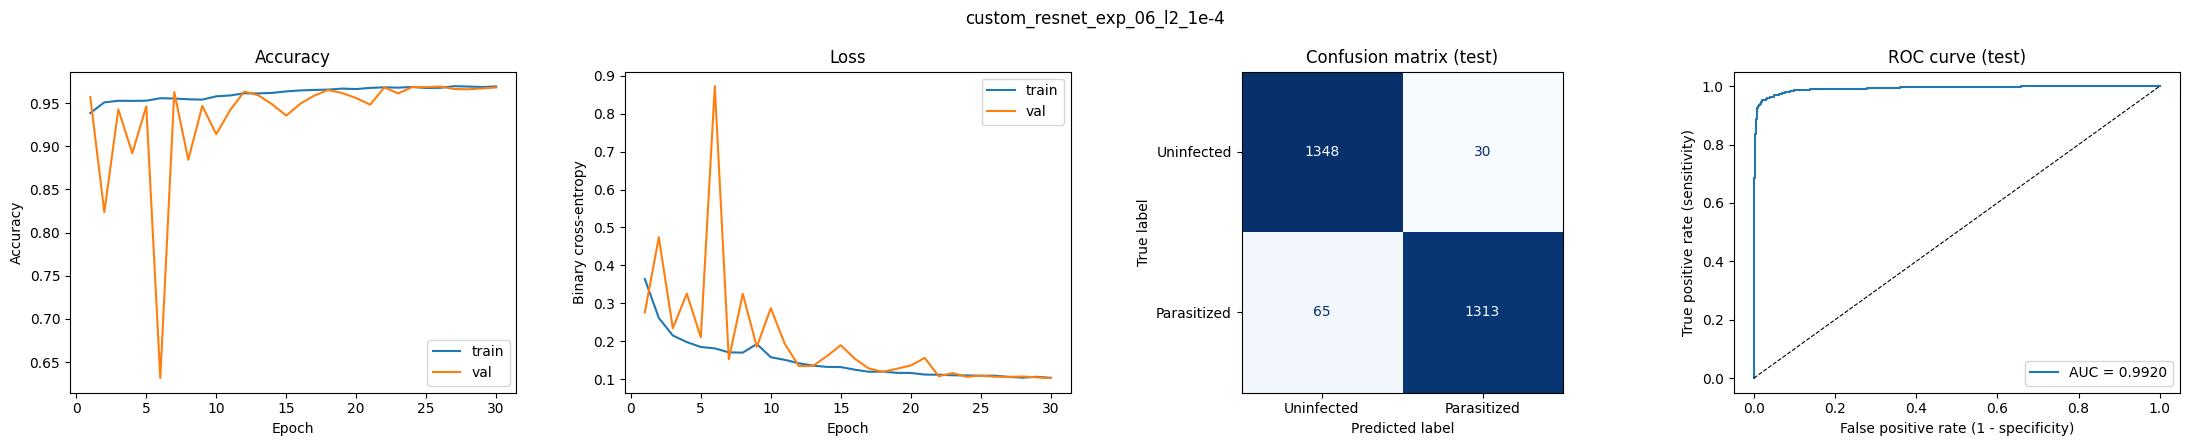

Best epoch: 30/30
Train acc 0.9692 | val acc 0.9681 | gap +0.0012
Train loss 0.1041 | val loss 0.1032

>>> custom_resnet_exp_06_l2_1e-4: val AUC 0.9944 vs custom_resnet_exp_05_augmentation_lossless 0.9950 -> DISCARD



In [ ]:
name = 'custom_resnet_exp_06_l2_1e-4'
CONFIG_06 = {**best_config, 'l2': 1e-4}
model, history, test_prob = run_and_plot(name, CONFIG_06)
diagnose_fit(history)
best_name, best_config = keep_if_better(name, CONFIG_06, best_name, best_config)

**Result:** L2 regularization reduced the gap between training and validation to almost zero: at the best epoch the training and validation accuracy were nearly the same (0.9692 vs 0.9681, +0.12 pts compared to +0.38 pts in exp 05). However, the overall performance decreased. The validation ROC-AUC dropped from 0.9950 to 0.9944, the validation sensitivity from 0.9666 to 0.9586, and the best validation loss was higher (0.1032 vs 0.0886). The training was also the least stable of all experiments in the early epochs, with validation loss spikes up to 0.47 at epoch 2 and 0.87 at epoch 6. The model trained for all 30 epochs and its best epoch was the last one, which means it was still improving when training stopped and did not fully converge within the epoch limit. This matches the expectation that the penalty slows down the learning, and that with BatchNormalization, L2 mostly changes how fast the weights are updated instead of improving generalisation. On the test set, the specificity increased (0.9782 vs 0.9702) but the sensitivity decreased (0.9528 vs 0.9594), so the model missed more infected cells than exp 05.

**Decision:** Discarded according to the selection rule (validation ROC-AUC 0.9944 < 0.9950). Exp 05 stays the best configuration.

### Experiment 07 — custom_resnet_exp_07_stem_stride2
**Change from best so far (exp 05):** stride-2 stem convolution, so stage 1 runs at 64×64 instead of 128×128 (≈4× less compute; the Grad-CAM map becomes 8×8). The lossless augmentation and learning-rate schedule from exp 05 are kept.

**Why:** The regularization experiments (dropout, augmentation, L2) only changed the results slightly, so this experiment tests the architecture itself. In the current design, stage 1 processes the full 128×128 image with 32 filters, which makes it the most expensive part of the network. Standard ResNets reduce the image size early, in the first layer, and the question is whether the full resolution is really needed to detect the parasites in these small cell images. This matters in practice: a model meant for malaria diagnosis in resource-constrained settings should be as cheap to run as possible. Halving the resolution in the stem gives about 4× less computation in every layer, while the number of parameters stays the same (about 2.8M), because the stride does not change the size of the filters.

**Expectation:** We expect the training to be much faster per epoch. Because each feature map has a lower resolution, some fine details of small parasites may be lost, so the sensitivity could decrease slightly compared to exp 05. If the parasites are still visible enough at 64×64, the validation ROC-AUC should stay close to exp 05 (0.9950). The Grad-CAM heatmaps will be coarser, because the last feature map is 8×8 instead of 16×16, so the explanations will be less precise.

Epoch 1/30


2026-10-06 19:45:38.102429: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-10-06 19:45:38.245200: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


688/689 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.9105 - auc: 0.9532 - loss: 0.2532 - precision: 0.9376 - recall: 0.8752

2026-10-06 19:46:20.707241: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-10-06 19:46:20.850325: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


689/689 ━━━━━━━━━━━━━━━━━━━━ 68s 70ms/step - accuracy: 0.9419 - auc: 0.9770 - loss: 0.1786 - precision: 0.9621 - recall: 0.9201 - val_accuracy: 0.8374 - val_auc: 0.9850 - val_loss: 0.3842 - val_precision: 0.9947 - val_recall: 0.6785 - learning_rate: 0.0010
Epoch 2/30
689/689 ━━━━━━━━━━━━━━━━━━━━ 35s 50ms/step - accuracy: 0.9557 - auc: 0.9838 - loss: 0.1441 - precision: 0.9687 - recall: 0.9418 - val_accuracy: 0.9583 - val_auc: 0.9879 - val_loss: 0.1531 - val_precision: 0.9752 - val_recall: 0.9405 - learning_rate: 0.0010
Epoch 3/30
689/689 ━━━━━━━━━━━━━━━━━━━━ 34s 50ms/step - accuracy: 0.9555 - auc: 0.9869 - loss: 0.1344 - precision: 0.9686 - recall: 0.9416 - val_accuracy: 0.9419 - val_auc: 0.9874 - val_loss: 0.1701 - val_precision: 0.9849 - val_recall: 0.8977 - learning_rate: 0.0010
Epoch 4/30
689/689 ━━━━━━━━━━━━━━━━━━━━ 35s 50ms/step - accuracy: 0.9580 - auc: 0.9877 - loss: 0.1271 - precision: 0.9709 - recall: 0.9444 - val_accuracy: 0.9601 - val_auc: 0.9917 - val_loss: 0.1172 - val_pr

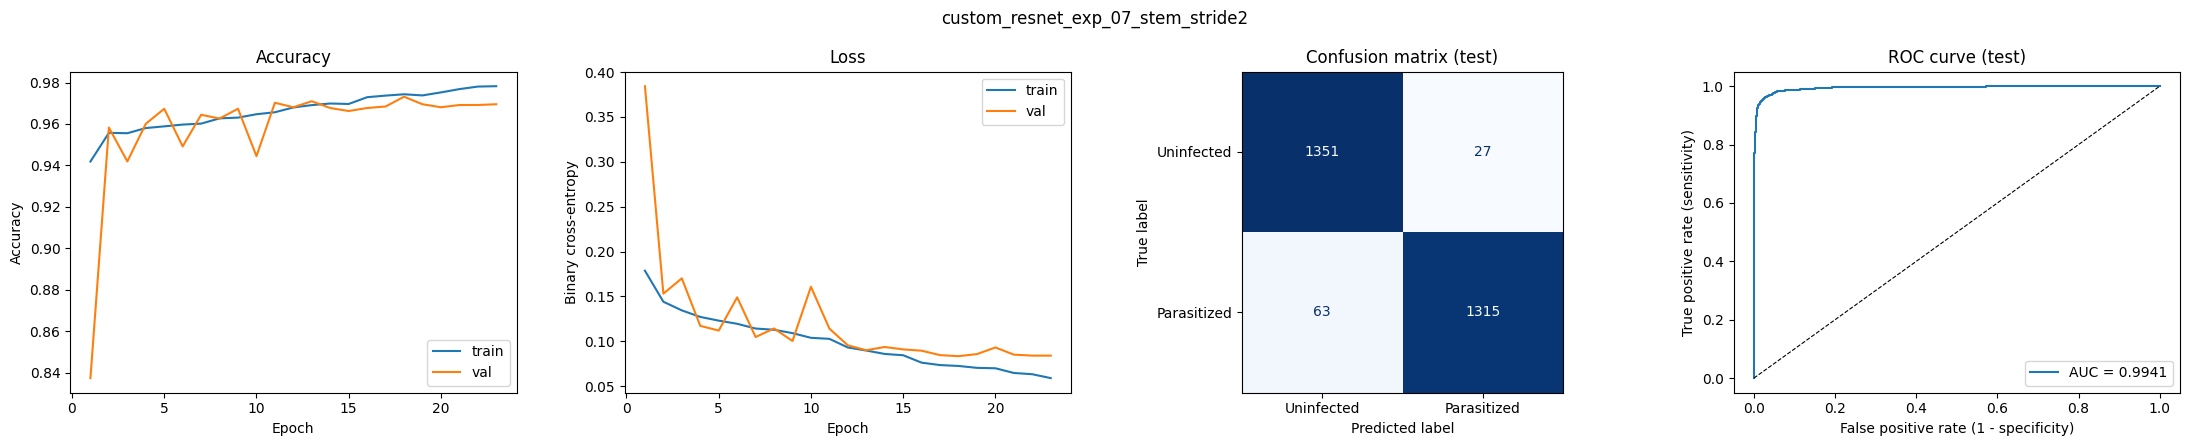

Best epoch: 18/23
Train acc 0.9743 | val acc 0.9731 | gap +0.0012
Train loss 0.0725 | val loss 0.0834

>>> custom_resnet_exp_07_stem_stride2: val AUC 0.9950 vs custom_resnet_exp_05_augmentation_lossless 0.9950 -> DISCARD

Best run: custom_resnet_exp_05_augmentation_lossless


In [ ]:
name = 'custom_resnet_exp_07_stem_stride2'
CONFIG_07 = {**best_config, 'stem_stride': 2}
model, history, test_prob = run_and_plot(name, CONFIG_07)
diagnose_fit(history)
best_name, best_config = keep_if_better(name, CONFIG_07, best_name, best_config)
print('Best run:', best_name)

**Result:** Reducing the resolution in the stem did not reduce the performance of the model. At the best epoch (18 out of 23), the training and validation accuracy were almost the same (0.9743 vs 0.9731, +0.12 pts), so there was no sign of overfitting. On the validation set, exp 07 obtained the best accuracy (0.9731), specificity (0.9855), F1 (0.9728) and the lowest validation loss (0.0834) of all experiments, and its ROC-AUC was the same as exp 05 (0.9950). As expected, the sensitivity was slightly lower than in exp 05 (0.9608 vs 0.9666 on validation, 0.9543 vs 0.9594 on test), which suggests that some fine details of the parasites are lost at the lower resolution. On the test set, exp 07 reached the highest accuracy (0.9673), F1 (0.9669) and ROC-AUC (0.9941) of all runs. The training was also about 3.3× faster (35 s per epoch instead of 116 s), for the same number of parameters.

**Decision:** Discarded according to the selection rule. Both runs have a validation ROC-AUC of 0.9950 when rounded to four decimals (0.99498 vs 0.99496 unrounded), and the rule compared the rounded values, so exp 07 was treated as a tie and was not kept. The difference is far too small to be meaningful, so exp 05 and exp 07 perform the same. Exp 05 remains the final model because it has the highest sensitivity, which is the most important metric for malaria diagnosis, while exp 07 is a strong alternative when computation is limited.

## 10. Results summary

In [ ]:
# Runs logged before a field existed used its default value
DEFAULTS = {'l2': 0.0, 'augment_settings': 'none', 'lr_schedule': 'none', 'stem_stride': 1,
            'transfer_learning': 'none (trained from scratch)', 'hardware': 'colab_gpu'}
for r in results:
  for k, v in DEFAULTS.items():
    if pd.isna(r.get(k, np.nan)):
      r[k] = v
pd.DataFrame(results).to_csv(RESULTS_CSV, index=False)
show_results('val')

,learning_rate,optimizer,batch_size,dropout,l2,augment_settings,lr_schedule,stage_filters,block_per_stage,stem_stride,epochs_run,hardware,val_accuracy,val_precision,val_recall_sensitivity,val_specificity,val_f1,val_roc_auc
experiment,,,,,,,,,,,,,,,,,,
custom_resnet_exp_01_baseline,0.001000,adam,32,0.000000,0.000000,none,none,"(32, 64, 128, 256)",2,1,12,kaggle_Tesla_T4,0.9637,0.9812,0.9456,0.9819,0.9630,0.9926
custom_resnet_exp_02_reduce_lr_plateau,0.001000,adam,32,0.000000,0.000000,none,plateau,"(32, 64, 128, 256)",2,1,23,kaggle_Tesla_T4,0.9724,0.9787,0.9659,0.9790,0.9722,0.9949
custom_resnet_exp_03_dropout_0.3,0.001000,adam,32,0.300000,0.000000,none,plateau,"(32, 64, 128, 256)",2,1,26,kaggle_Tesla_T4,0.9713,0.9751,0.9673,0.9753,0.9712,0.9942
custom_resnet_exp_04_augmentation,0.001000,adam,32,0.000000,0.000000,flip_hv + rotation_0.25 + zoom_0.1 (constant black fill),plateau,"(32, 64, 128, 256)",2,1,14,kaggle_Tesla_T4,0.9659,0.9820,0.9492,0.9826,0.9653,0.9931
custom_resnet_exp_05_augmentation_lossless,0.001000,adam,32,0.000000,0.000000,"flip_hv + transpose (8 lossless orientations, no interpolation)",plateau,"(32, 64, 128, 256)",2,1,27,kaggle_Tesla_T4,0.9702,0.9737,0.9666,0.9739,0.9701,0.9950
custom_resnet_exp_06_l2_1e-4,0.001000,adam,32,0.000000,0.000100,"flip_hv + transpose (8 lossless orientations, no interpolation)",plateau,"(32, 64, 128, 256)",2,1,30,kaggle_Tesla_T4,0.9681,0.9771,0.9586,0.9775,0.9678,0.9944
custom_resnet_exp_07_stem_stride2,0.001000,adam,32,0.000000,0.000000,"flip_hv + transpose (8 lossless orientations, no interpolation)",plateau,"(32, 64, 128, 256)",2,2,23,kaggle_Tesla_T4,0.9731,0.9851,0.9608,0.9855,0.9728,0.9950


In [ ]:
show_results('test')

,learning_rate,optimizer,batch_size,dropout,l2,augment_settings,lr_schedule,stage_filters,block_per_stage,stem_stride,epochs_run,hardware,test_accuracy,test_precision,test_recall_sensitivity,test_specificity,test_f1,test_roc_auc
experiment,,,,,,,,,,,,,,,,,,
custom_resnet_exp_01_baseline,0.001000,adam,32,0.000000,0.000000,none,none,"(32, 64, 128, 256)",2,1,12,kaggle_Tesla_T4,0.9604,0.9832,0.9369,0.9840,0.9595,0.9910
custom_resnet_exp_02_reduce_lr_plateau,0.001000,adam,32,0.000000,0.000000,none,plateau,"(32, 64, 128, 256)",2,1,23,kaggle_Tesla_T4,0.9634,0.9712,0.9550,0.9717,0.9630,0.9926
custom_resnet_exp_03_dropout_0.3,0.001000,adam,32,0.300000,0.000000,none,plateau,"(32, 64, 128, 256)",2,1,26,kaggle_Tesla_T4,0.9637,0.9747,0.9521,0.9753,0.9633,0.9920
custom_resnet_exp_04_augmentation,0.001000,adam,32,0.000000,0.000000,flip_hv + rotation_0.25 + zoom_0.1 (constant black fill),plateau,"(32, 64, 128, 256)",2,1,14,kaggle_Tesla_T4,0.9565,0.9736,0.9383,0.9746,0.9557,0.9907
custom_resnet_exp_05_augmentation_lossless,0.001000,adam,32,0.000000,0.000000,"flip_hv + transpose (8 lossless orientations, no interpolation)",plateau,"(32, 64, 128, 256)",2,1,27,kaggle_Tesla_T4,0.9648,0.9699,0.9594,0.9702,0.9646,0.9936
custom_resnet_exp_06_l2_1e-4,0.001000,adam,32,0.000000,0.000100,"flip_hv + transpose (8 lossless orientations, no interpolation)",plateau,"(32, 64, 128, 256)",2,1,30,kaggle_Tesla_T4,0.9655,0.9777,0.9528,0.9782,0.9651,0.9920
custom_resnet_exp_07_stem_stride2,0.001000,adam,32,0.000000,0.000000,"flip_hv + transpose (8 lossless orientations, no interpolation)",plateau,"(32, 64, 128, 256)",2,2,23,kaggle_Tesla_T4,0.9673,0.9799,0.9543,0.9804,0.9669,0.9941


## 11. Experiment tracking (TensorBoard)
All 7 runs were logged to TensorBoard during training (`logs/fit/<run_name>`): per-epoch training and validation loss, accuracy, AUC, precision, recall and learning rate, the hyperparameters of each run (HParams tab) and its final validation and test metrics.

**To view the results without retraining**, run only: the `pip install` cell, **1. Imports**, **2. Environment and configuration**, **8. Helpers**, then the two cells below.

The raw log directories are shared at: https://drive.google.com/drive/folders/10ZIzY-3yfIosUhwmFqY8Rt0qesSX0slK

In [ ]:
# Live TensorBoard dashboard. It needs a running session: in a saved or exported copy of
# this notebook it appears blank, so the charts below and the next cell's figure are kept.
print('Runs:', sorted(os.listdir(LOG_ROOT)))
if IN_KAGGLE:
  print('Kaggle cannot display TensorBoard inline - open this notebook in Colab or a local Jupyter session.')
else:
  get_ipython().run_line_magic('reload_ext', 'tensorboard')
  get_ipython().run_line_magic('tensorboard', f'--logdir "{LOG_ROOT}"')

Runs: ['custom_resnet_exp_01_baseline', 'custom_resnet_exp_02_reduce_lr_plateau', 'custom_resnet_exp_03_dropout_0.3', 'custom_resnet_exp_04_augmentation', 'custom_resnet_exp_05_augmentation_lossless', 'custom_resnet_exp_06_l2_1e-4', 'custom_resnet_exp_07_stem_stride2']


<IPython.core.display.Javascript object>

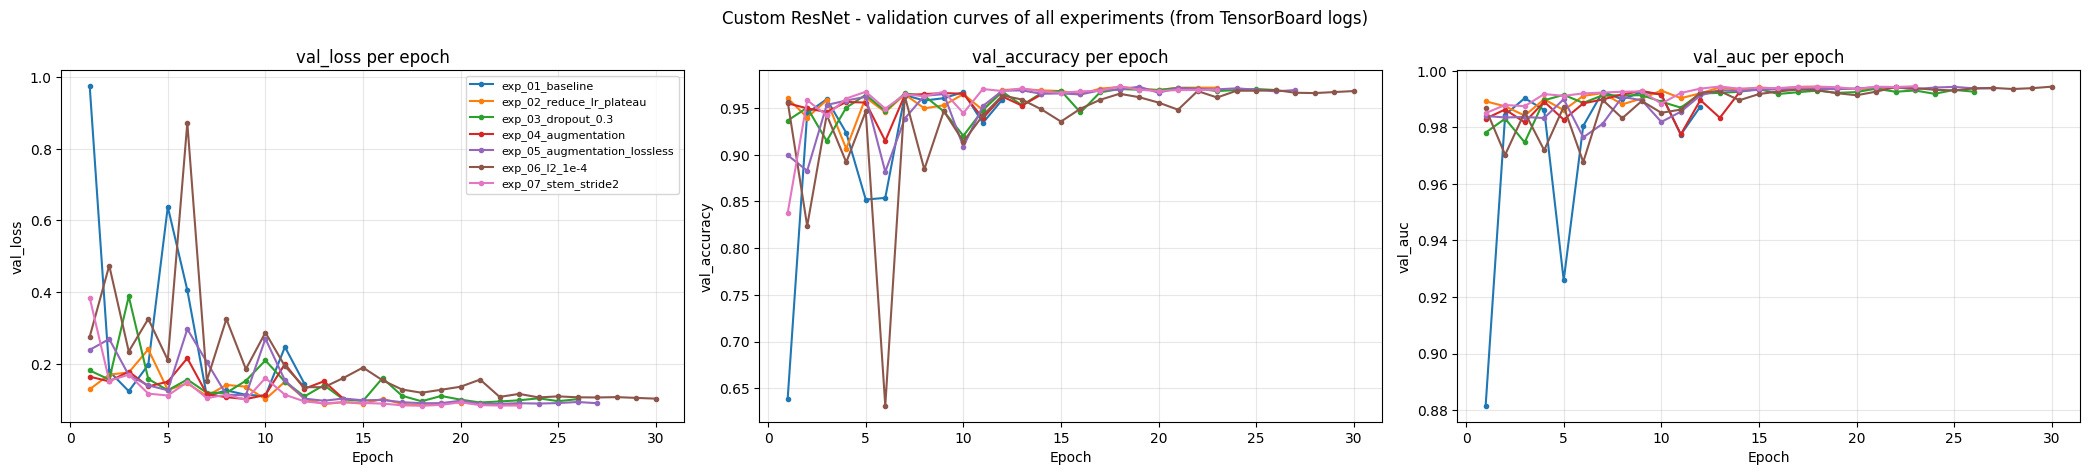

In [ ]:
def plot_run_comparison(
    metrics=('val_loss', 'val_accuracy', 'val_auc')
    ):
  """This function plots Validation curves of every logged run on 
  shared axes, read from the TensorBoard event files
  """
  runs = sorted(os.listdir(LOG_ROOT))
  fig, ax = plt.subplots(1, len(metrics), figsize=(7 * len(metrics), 4.8))
  for name in runs:
    h = history_from_tensorboard(name).history
    for a, m in zip(ax, metrics):
      if m in h:
        a.plot(range(1, len(h[m]) + 1), h[m], marker='.', label=name.replace('custom_resnet_', ''))
  for a, m in zip(ax, metrics):
    a.set(title=f'{m} per epoch', xlabel='Epoch', ylabel=m)
    a.grid(alpha=0.3)
  ax[0].legend(fontsize=8)
  fig.suptitle('Custom ResNet - validation curves of all experiments (from TensorBoard logs)')
  plt.tight_layout(); plt.show()

plot_run_comparison()

**TensorBoard results** (drawn from the TensorBoard event logs, smoothing 0; circles mark the epoch kept by early stopping)

**Validation loss per epoch - all experiments**

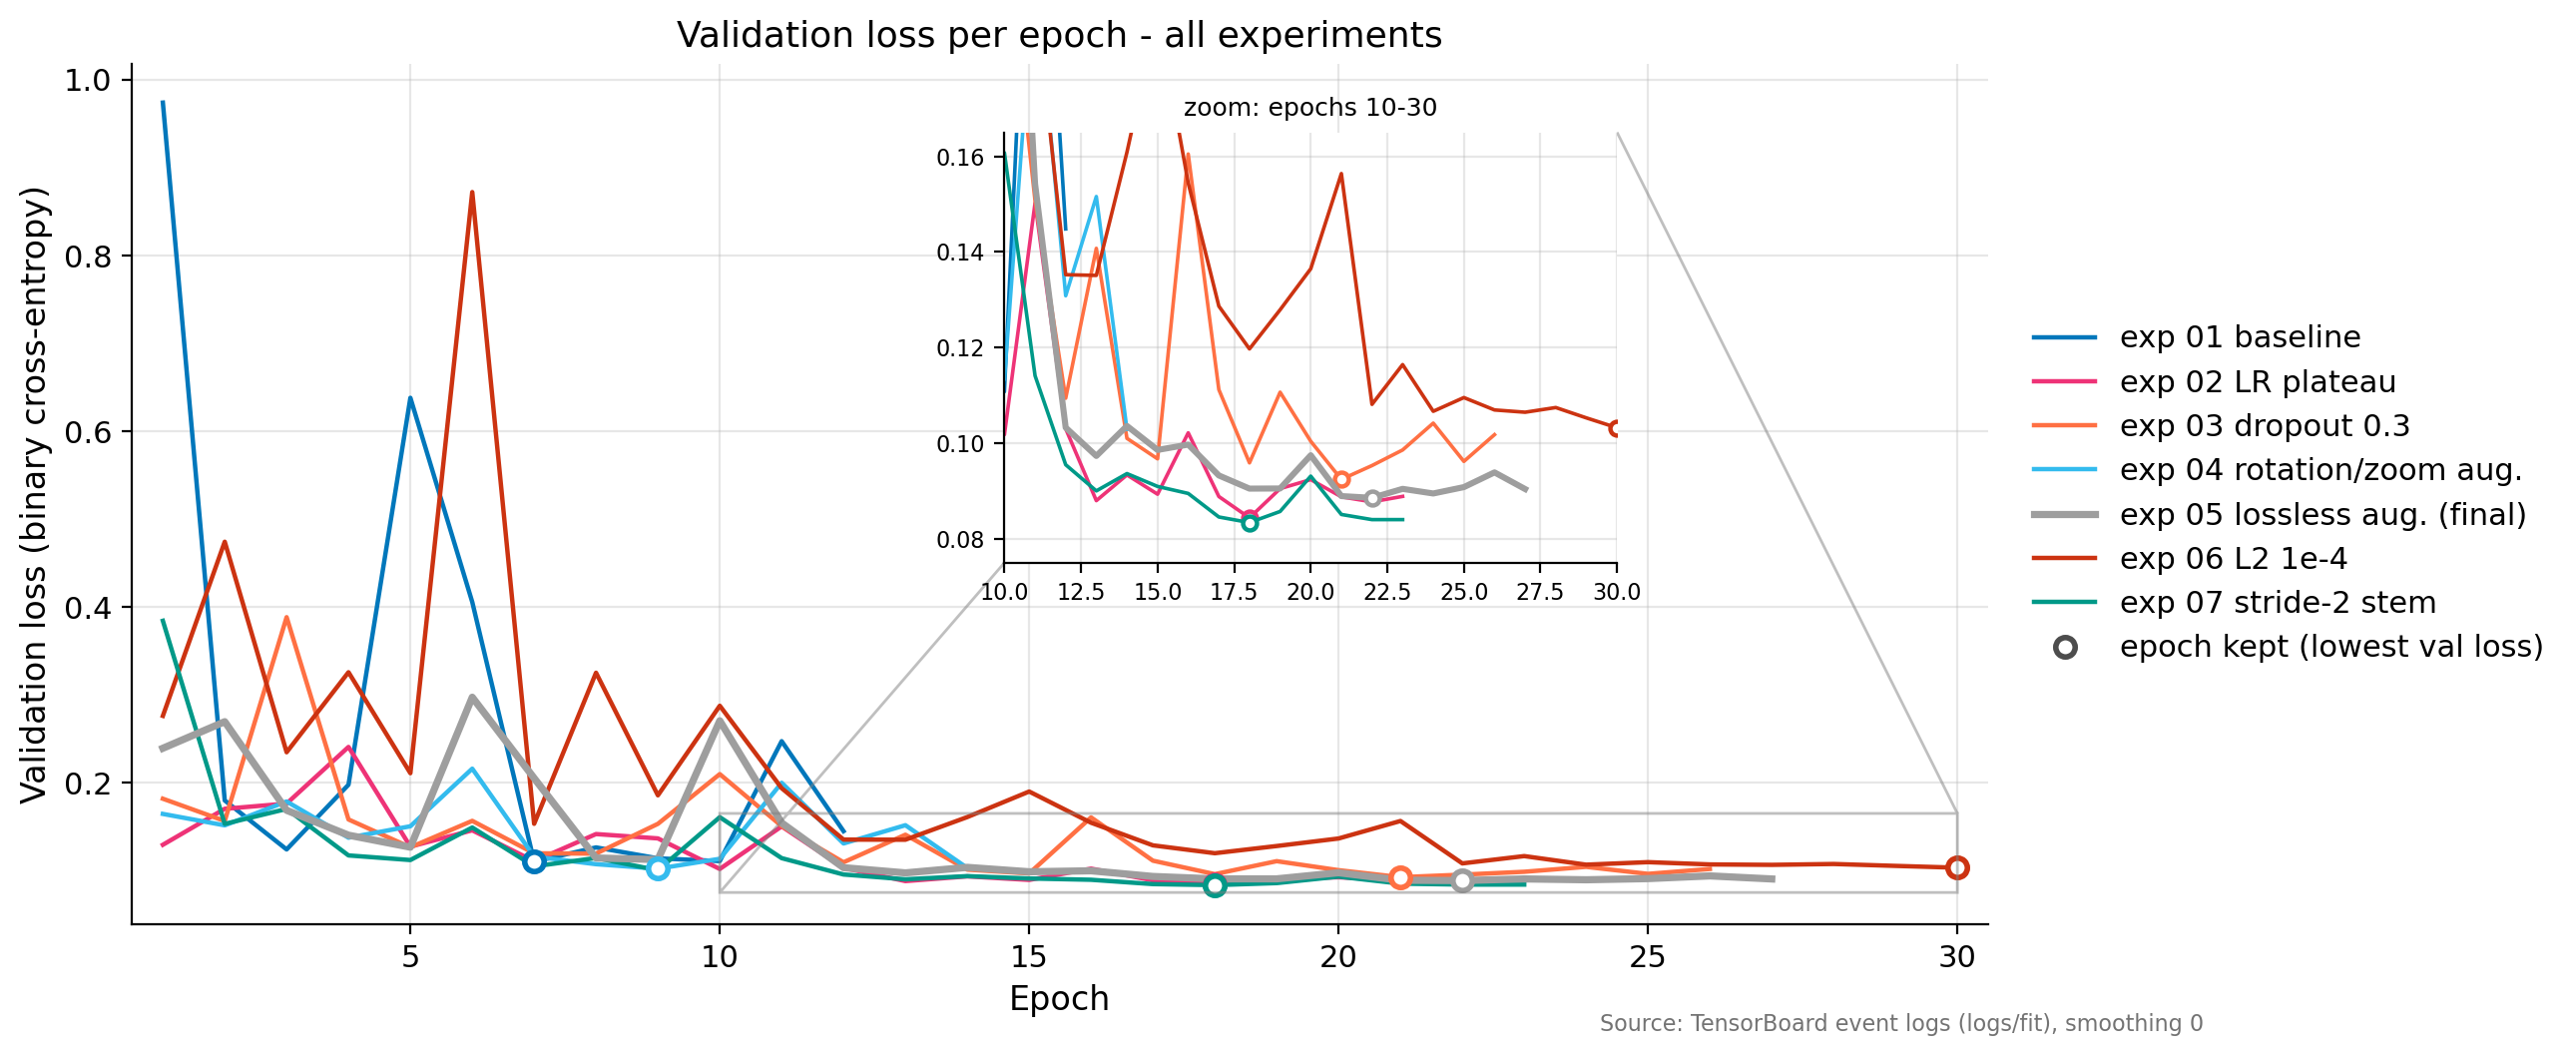

**Validation accuracy per epoch - all experiments**

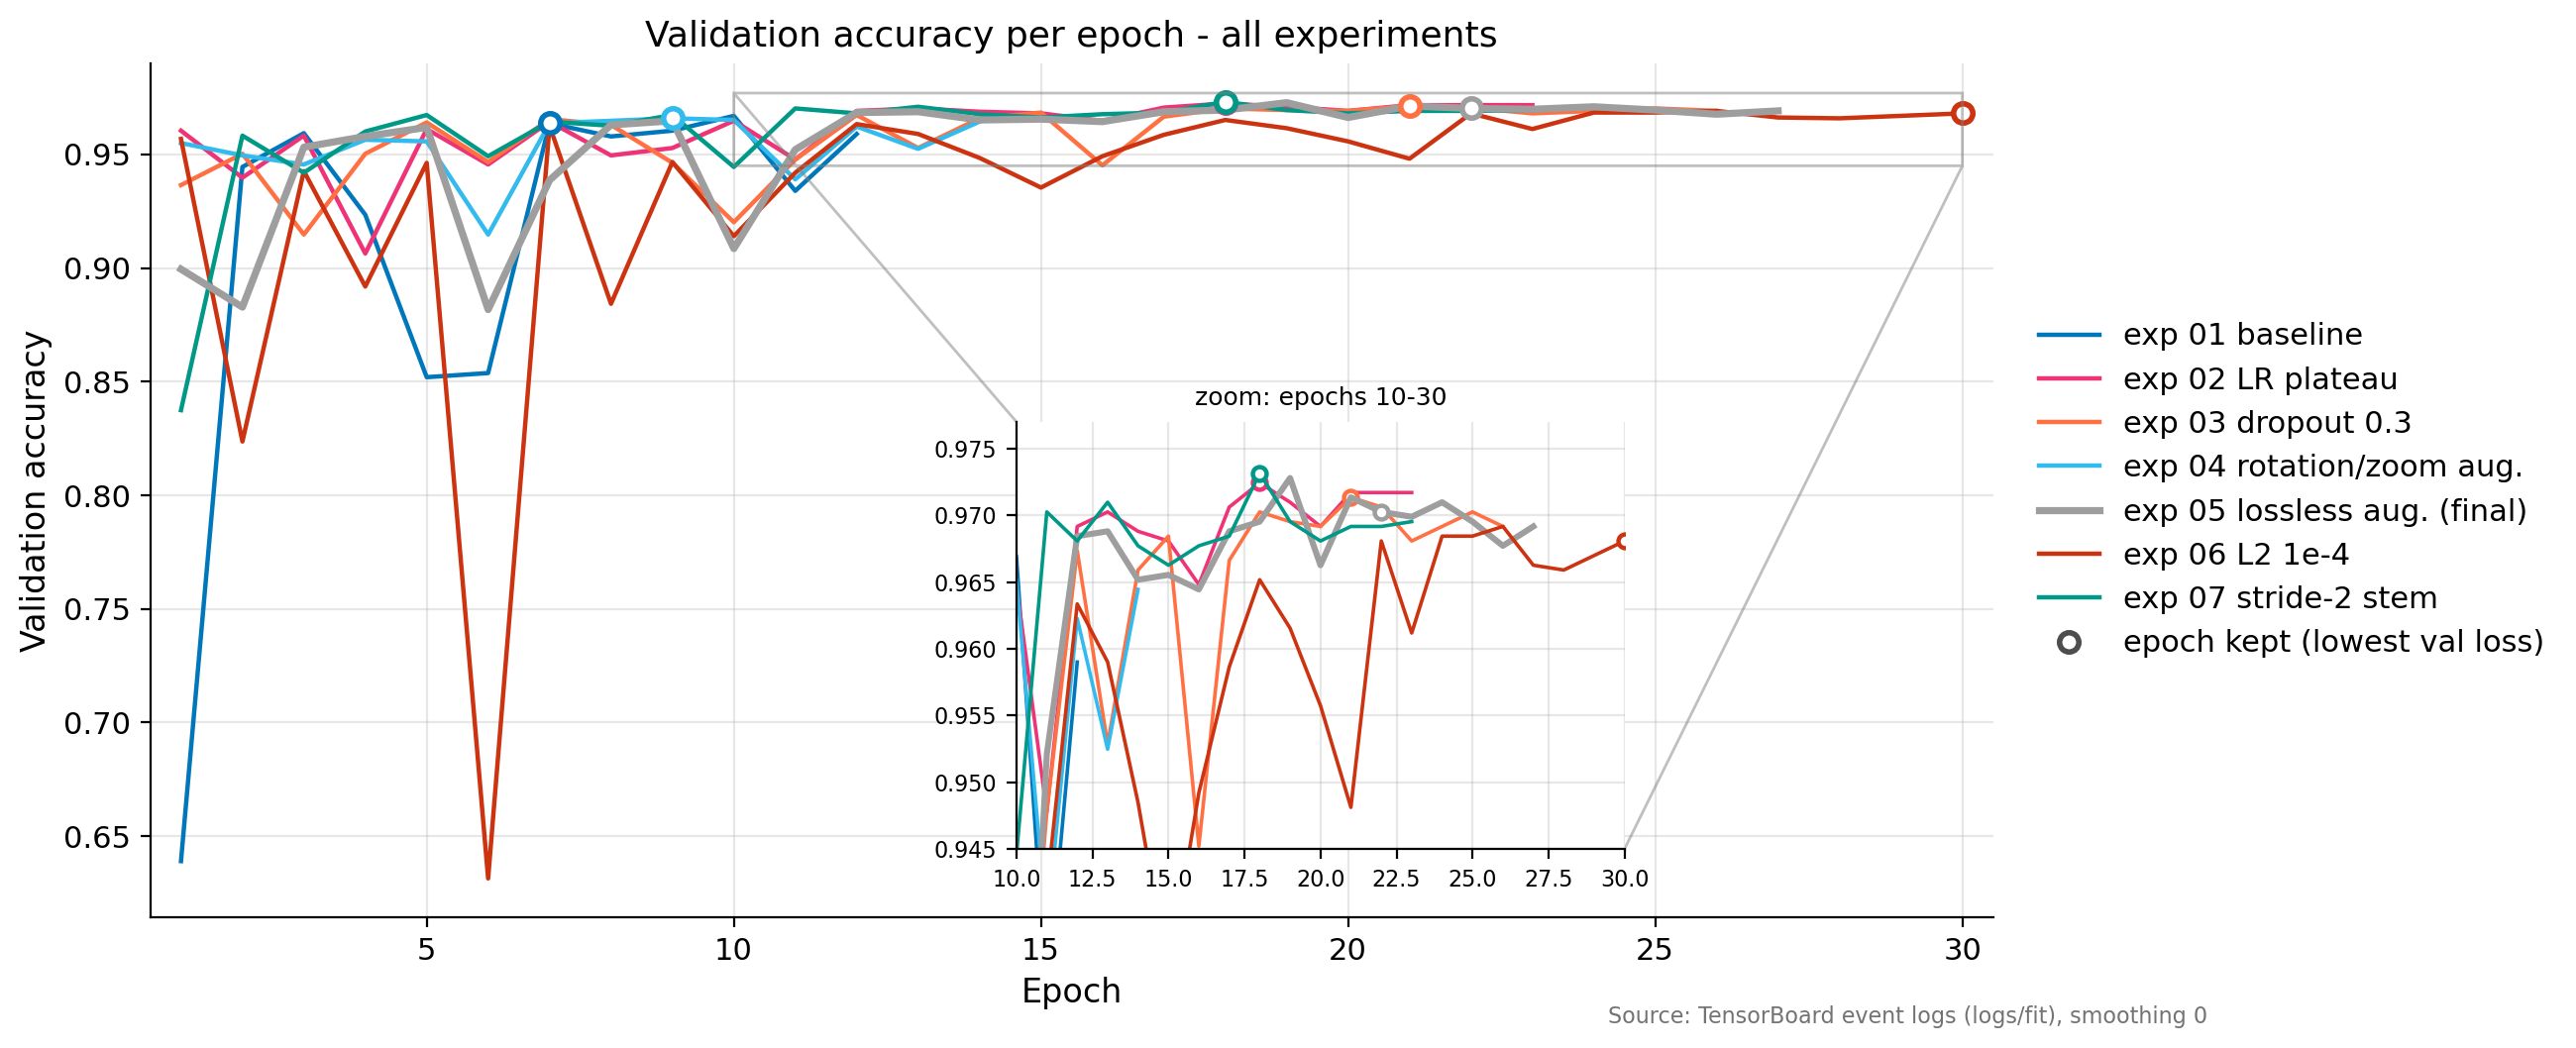

**Validation ROC-AUC per epoch - all experiments**

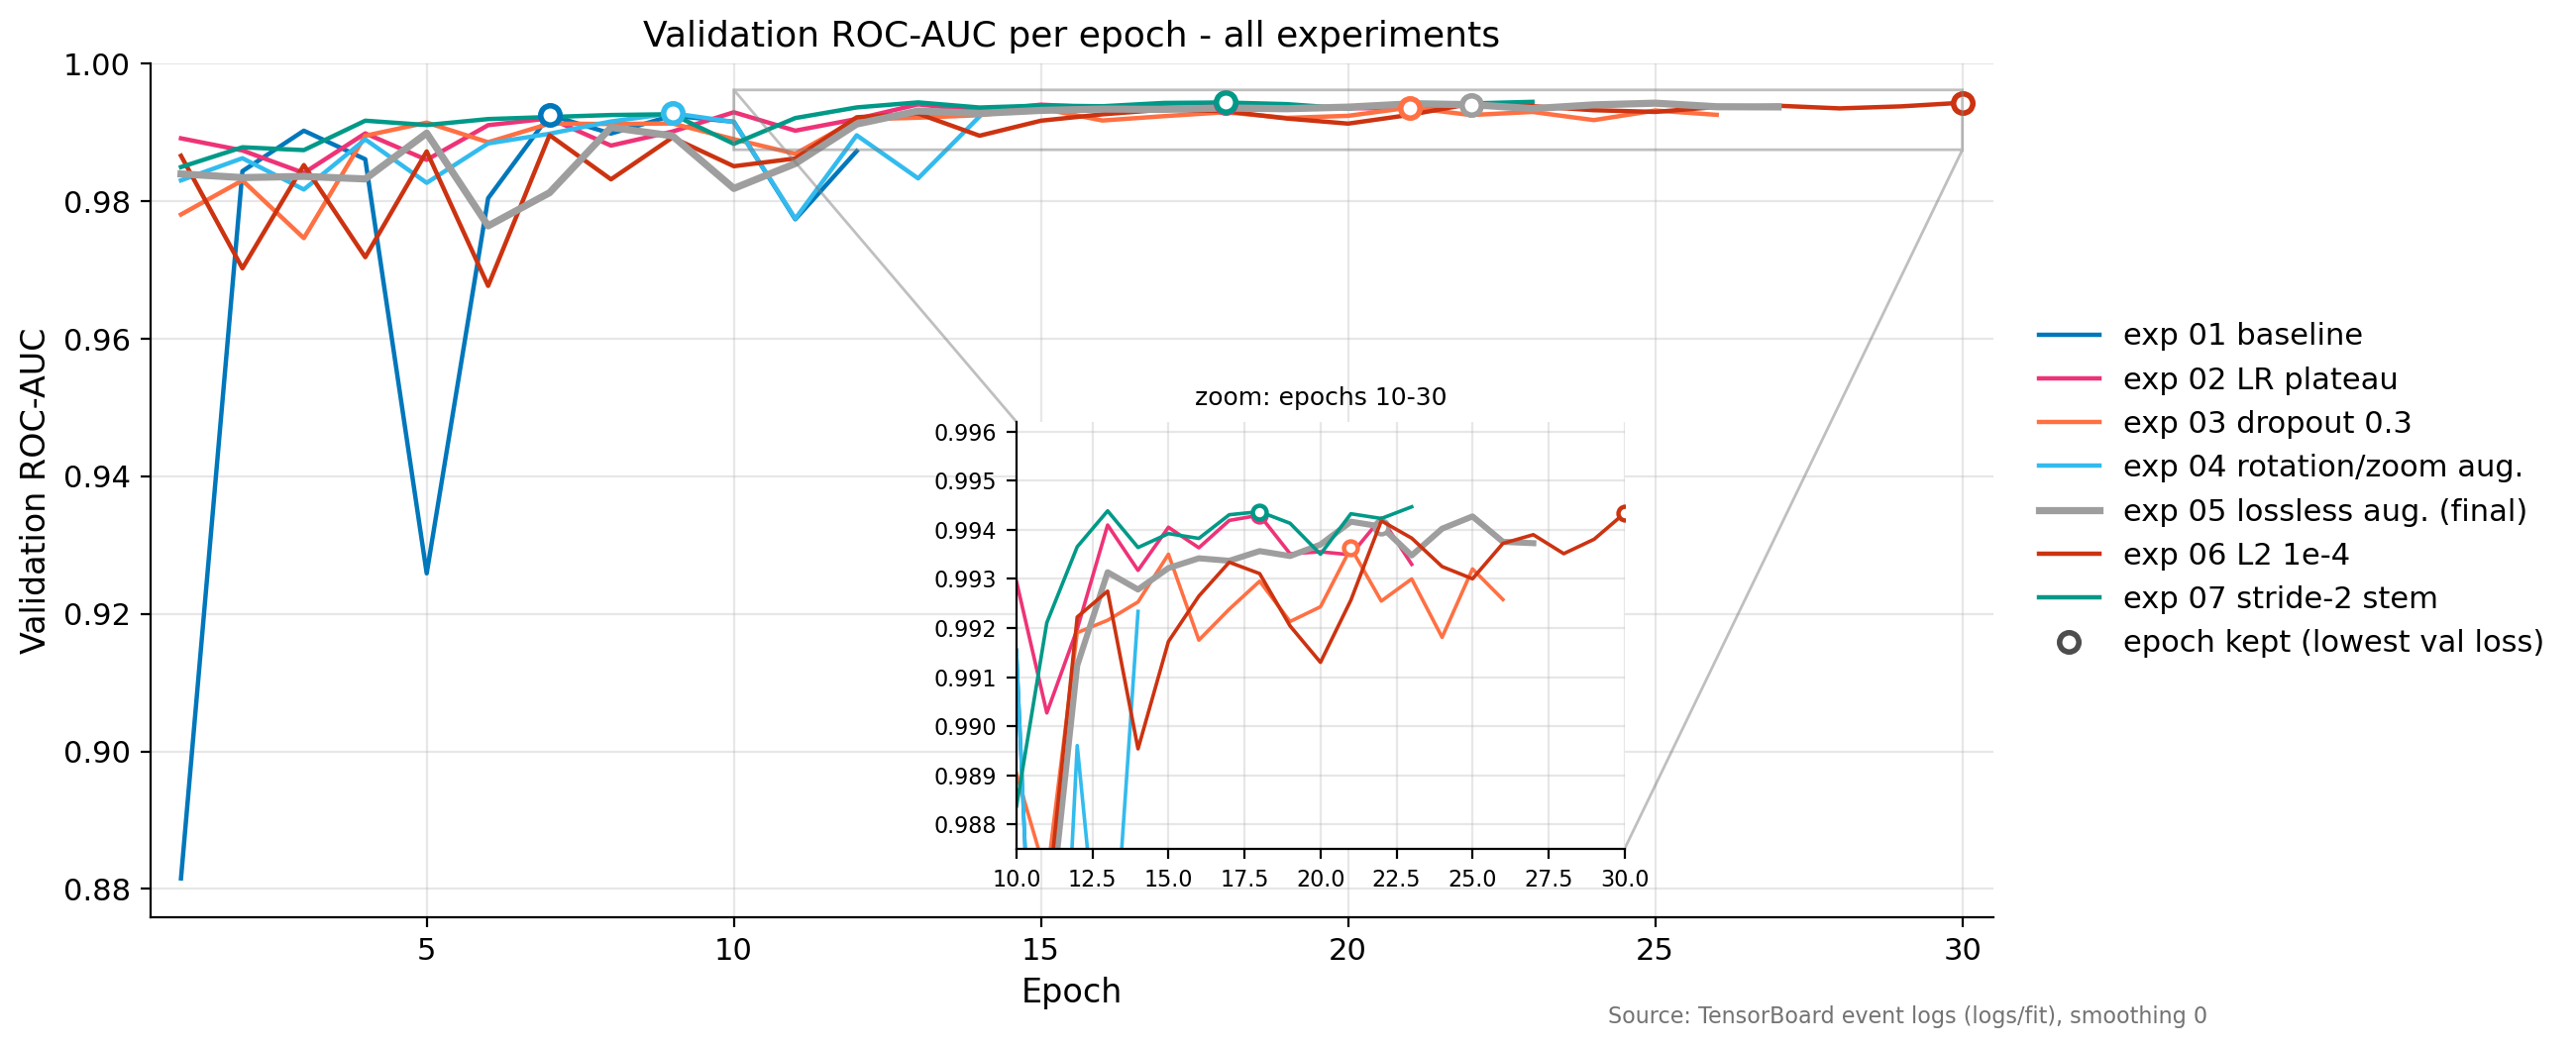

**Learning rate per epoch (ReduceLROnPlateau)**

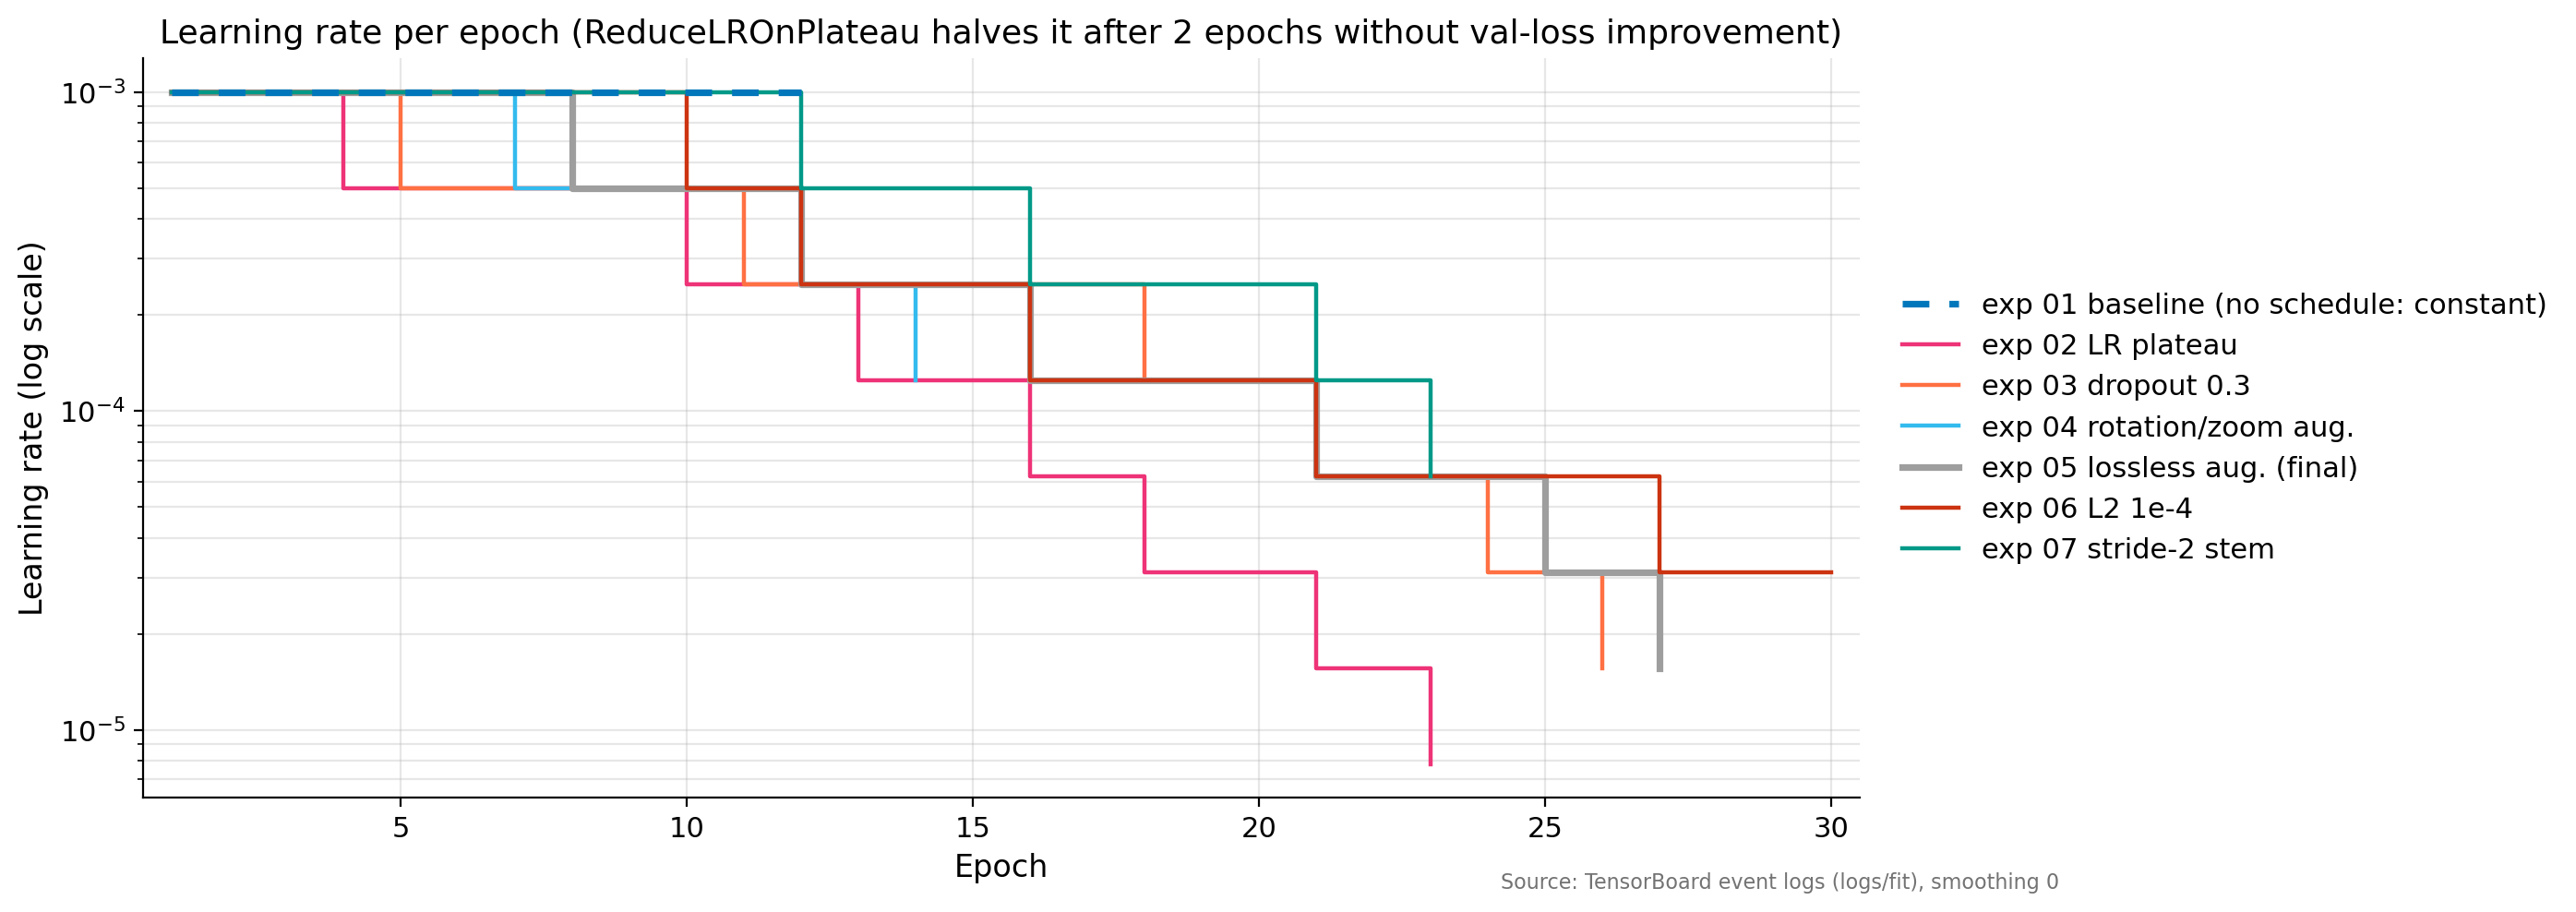

**Results of all 7 experiments (TensorBoard final metrics)**

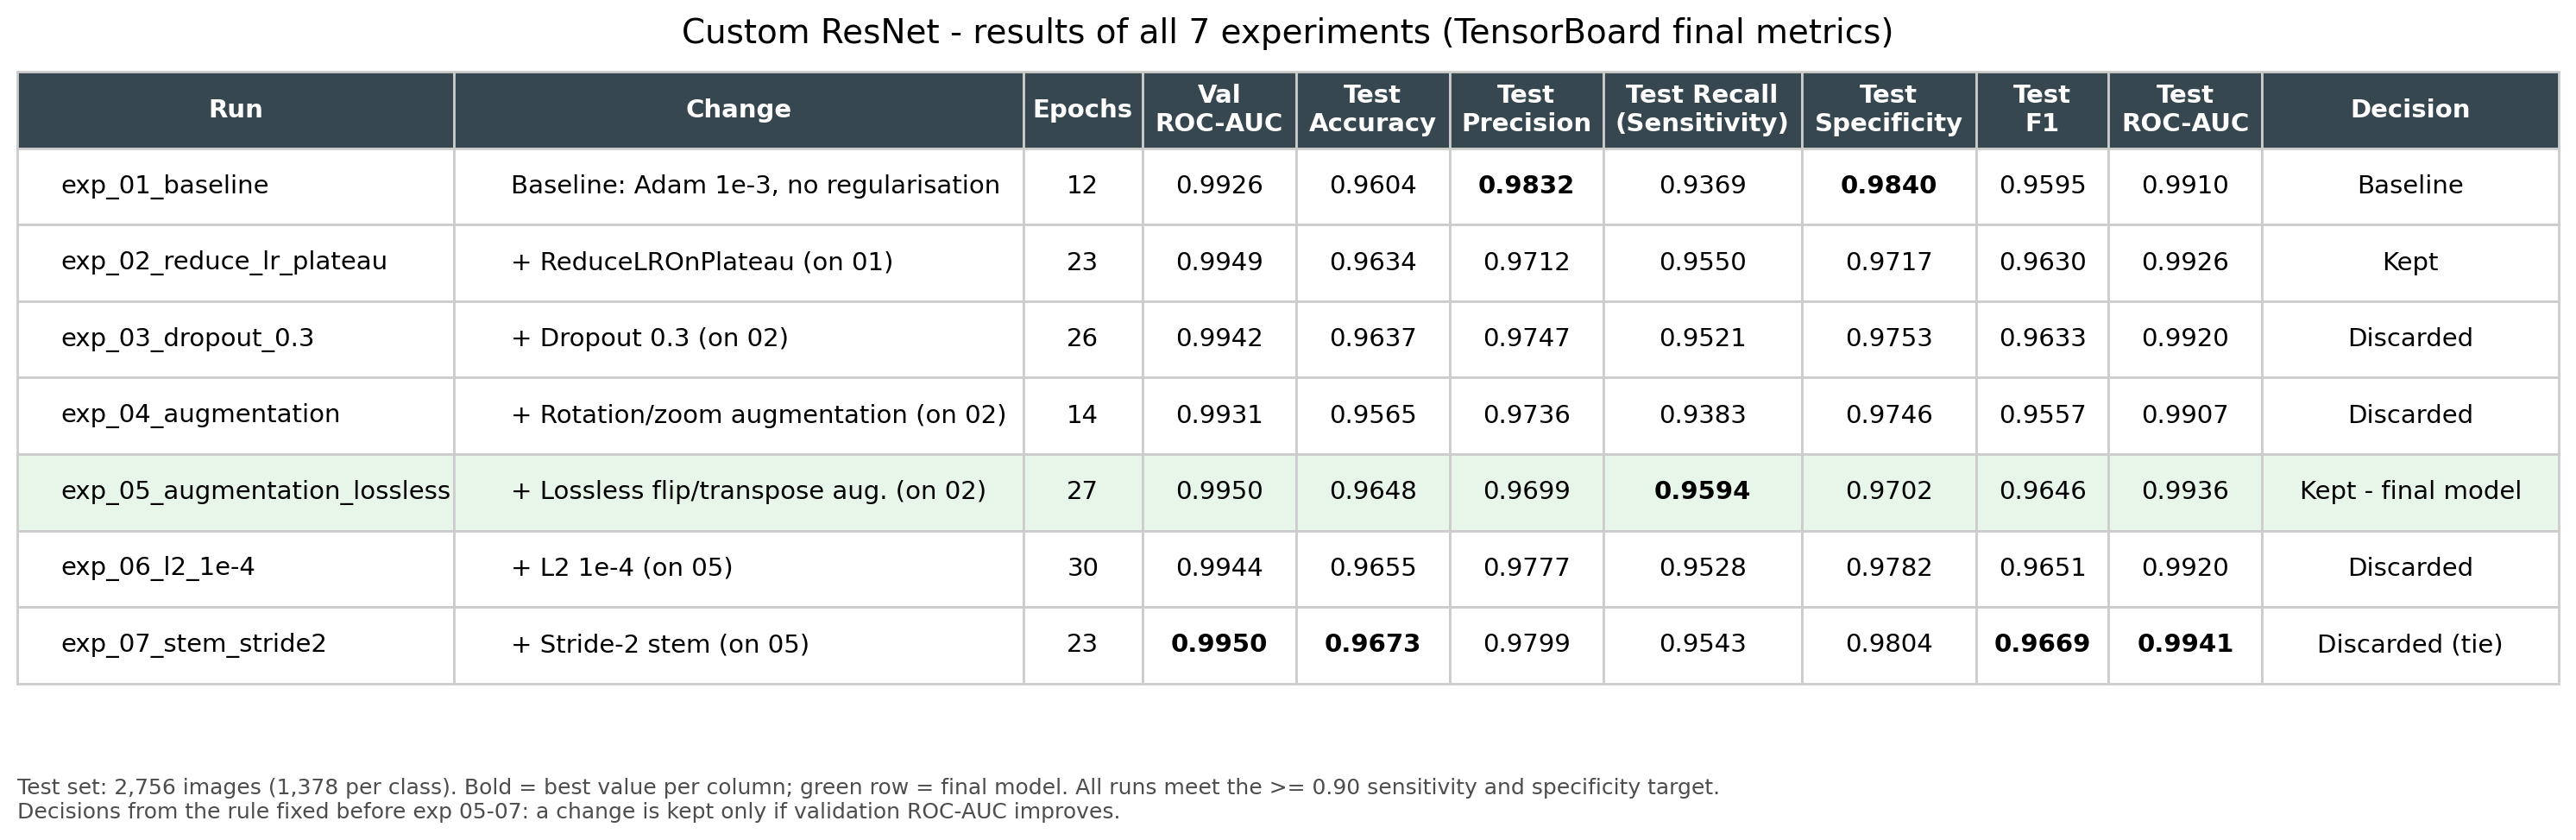

**What the run comparison shows:** 
All seven experiments show the same pattern: the validation loss is unstable in the first epochs and becomes stable later. The largest spikes come from the baseline (0.974 at epoch 1 and 0.638 at epoch 5) and from exp 06 with L2 (0.87 at epoch 6). In the runs with ReduceLROnPlateau, the curves become smooth after about epoch 12, once the learning rate has been halved two or three times (learning rate chart), and the validation loss settles between 0.08 and 0.10. The learning-rate schedule was therefore the change with the clearest effect: it stabilised the training and allowed the models to train longer (23–30 epochs instead of 12 for the baseline). The other changes had much smaller effects. After epoch 12, the validation accuracy of all runs is between about 0.95 and 0.97, and the validation ROC-AUC is above 0.99 for every run, with final values between 0.9926 and 0.9950. These differences are within the noise of the validation set, so most experiments perform almost the same. Two runs behave differently: exp 04 (rotation and zoom augmentation) stopped early at epoch 14 with a lower sensitivity, and exp 06 (L2) was still improving when it reached the 30-epoch limit. In the results table, all experiments meet the target of at least 0.90 sensitivity and specificity on the test set. Exp 05 has the highest test sensitivity (0.9594), which is why it was kept as the final model, while exp 07 has the highest test accuracy, F1 and ROC-AUC with about 3.3× less training time.

## 12. Final model: evaluation, error analysis and Grad-CAM
Uses the best run selected above, rebuilt from its checkpoint so no training is needed.

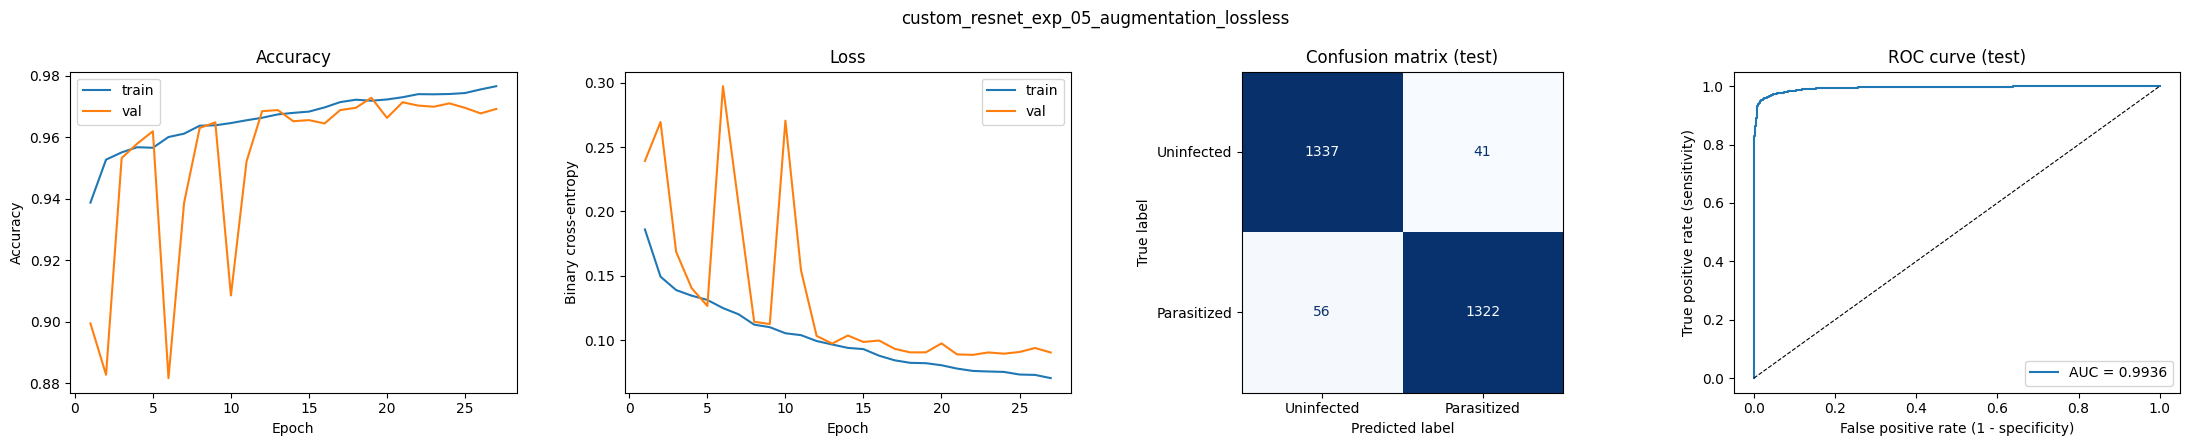

Best epoch: 22/27
Train acc 0.9740 | val acc 0.9702 | gap +0.0037
Train loss 0.0761 | val loss 0.0886


In [ ]:
FINAL_RUN, FINAL_CONFIG = best_name, best_config
final_ckpt = os.path.join(CKPT_ROOT, f'{FINAL_RUN}.weights.h5')
if os.path.exists(final_ckpt):
  final_model, final_prob = load_run(FINAL_RUN, FINAL_CONFIG)
  final_history = history_from_tensorboard(FINAL_RUN)
  plot_final(final_history, test_y, final_prob, FINAL_RUN)
  diagnose_fit(final_history)
else:
  final_model = None
  print(f'Checkpoint for {FINAL_RUN} not found in {CKPT_ROOT} - run this section where it is stored.')

**Final model (exp 05) - training vs validation loss, with the epoch kept by early stopping**

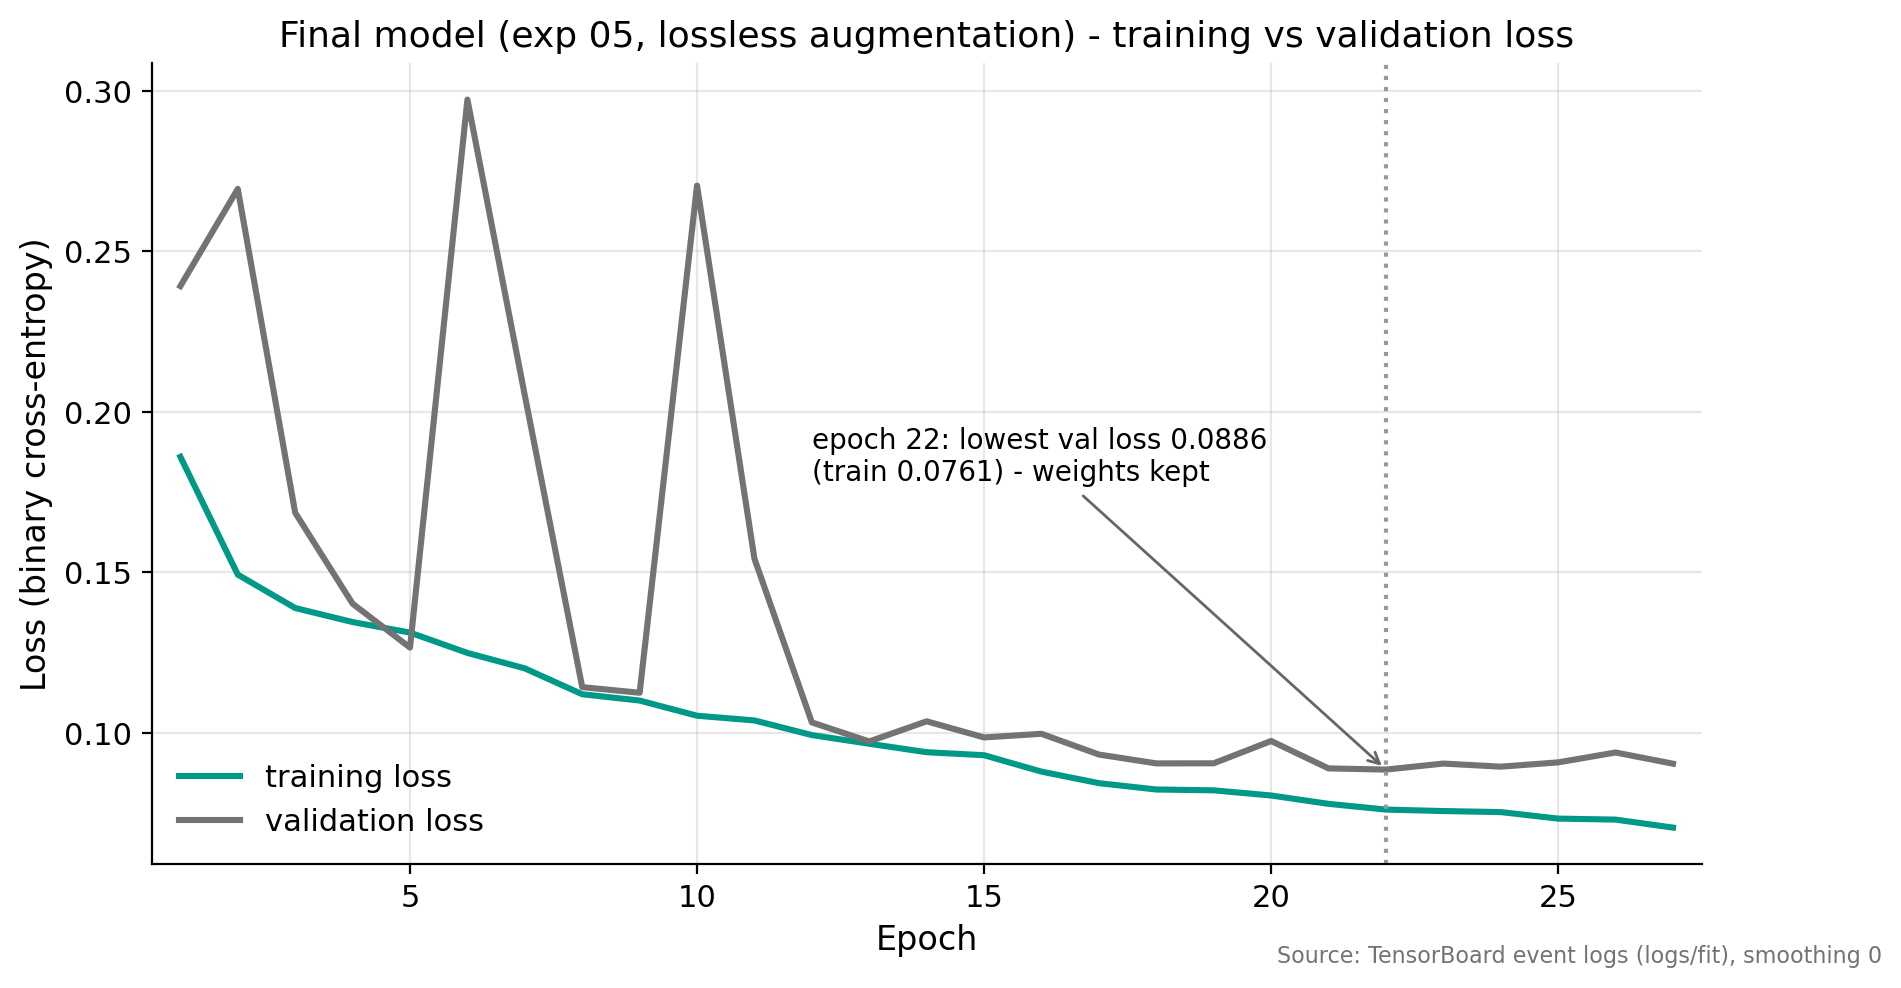

**Interpretation of the four plots:** <...>
Interpretation of the four plots:

**Accuracy:** The training accuracy increases smoothly from 0.939 to about 0.977. The validation accuracy drops sharply at epochs 2, 6 and 10 (down to about 0.88–0.91), then follows the training accuracy closely from about epoch 12, when the learning rate starts to decrease. At the best epoch (22) the two are very close (0.9740 vs 0.9702), so the model generalises well.

**Loss:** The training loss decreases smoothly from 0.186 to about 0.071, while the validation loss shows three spikes in the early epochs (around 0.27–0.30 at epochs 2, 6 and 10), the same instability seen in the other experiments. After the learning rate is reduced (first at epoch 7), the validation loss becomes stable and reaches its lowest value of 0.0886 at epoch 22, against 0.0761 for the training loss. After epoch 22 the training loss keeps decreasing while the validation loss stays around 0.09, which is an early sign of overfitting. Early stopping ended the training at epoch 27 and restored the weights from epoch 22, so the final model was taken before this overfitting grew.

**Confusion matrix:** On the 2,756 test images, the model classified 1,337 uninfected and 1,322 parasitized cells correctly. It made 41 false positives (uninfected cells predicted as parasitized) and 56 false negatives (infected cells predicted as uninfected). This gives a sensitivity of 0.9594 and a specificity of 0.9702, both above the 0.90 target. The model makes more false negatives than false positives, and false negatives are the most dangerous error in malaria diagnosis, because an infected patient would not receive treatment.

**ROC curve:** The ROC-AUC of 0.9936 shows that the model separates infected and uninfected cells very well: the curve stays very close to the top-left corner for almost all thresholds. The confusion matrix uses a threshold of 0.5, which is only one point on this curve (sensitivity 0.9594, false positive rate 0.0298). Because the curve is so close to the top-left corner, lowering the threshold could increase the sensitivity and reduce the number of missed infections while losing only a little specificity.

False negatives: 56   False positives: 41


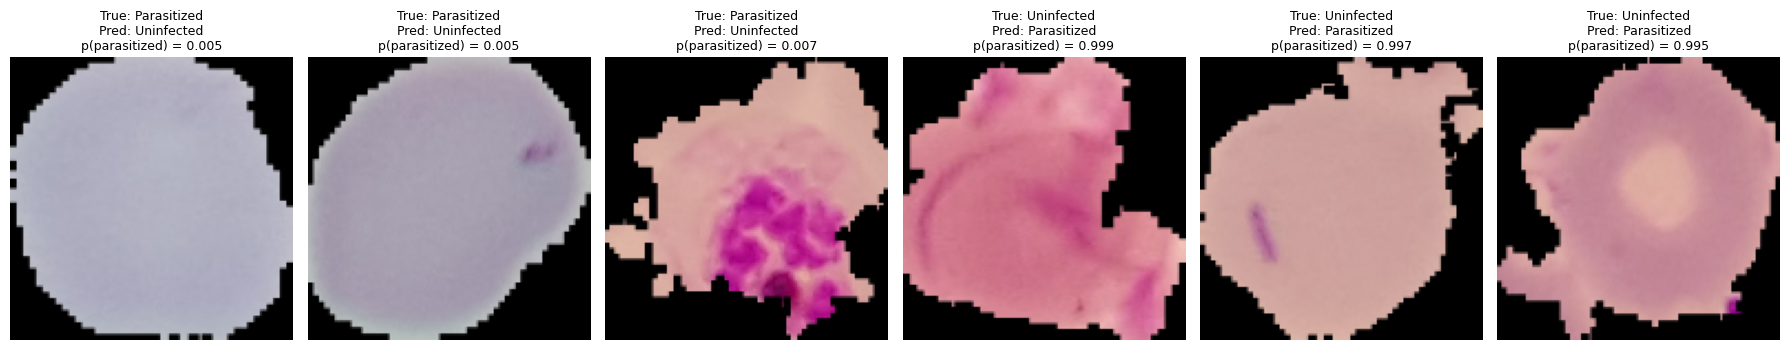

In [ ]:
if final_model is not None:
  show_errors(final_prob)

**Error analysis:** On the test set the final model made 97 errors out of 2,756 images: 56 false negatives (infected cells predicted as uninfected) and 41 false positives. The figure shows the three most confident errors of each type, and all of them were predicted with very high confidence (probability of parasitized 0.005–0.007 for the false negatives and 0.995–0.999 for the false positives), so the model is often very sure even when it is wrong.

Two of the false negatives are pale, grey-purple cells, a different staining colour from most images in the dataset, which are pink. In the first one no parasite is visible, and in the second one there is only a small faint purple mark at the edge of the cell. The parasite is therefore either too small and faint for the model to detect, or not present, which would mean the image may be mislabeled. The third false negative is surprising: it contains a large, clearly stained purple mass, but the cell shape is irregular and very different from the round ring-shaped parasites that are common in the training images, so the model may not have learned this less common appearance.

The false positives show the opposite problem. The first one has dark pink folds and streaks in the cell, which look like stained structures, the second one contains an elongated dark purple shape, and the third one has a small dark spot at the very edge of the cell. These could be staining artifacts, debris or platelets lying on the cell, which the model confuses with parasites because they have a similar colour. However, some of these marks also look like real parasites, so some of these "errors" may come from labeling mistakes in the dataset rather than from the model.

Regarding overfitting and underfitting, the model is not underfitting, since the training and validation accuracy are both high and close at the best epoch (0.9740 vs 0.9702). It shows only a mild sign of overfitting after epoch 22, when the training loss keeps decreasing while the validation loss stops improving, and early stopping restored the weights from epoch 22 before this became a problem. The errors therefore seem to come mainly from difficult or ambiguous images, such as faint parasites, unusual staining, artifacts and possible label noise, rather than from overfitting.


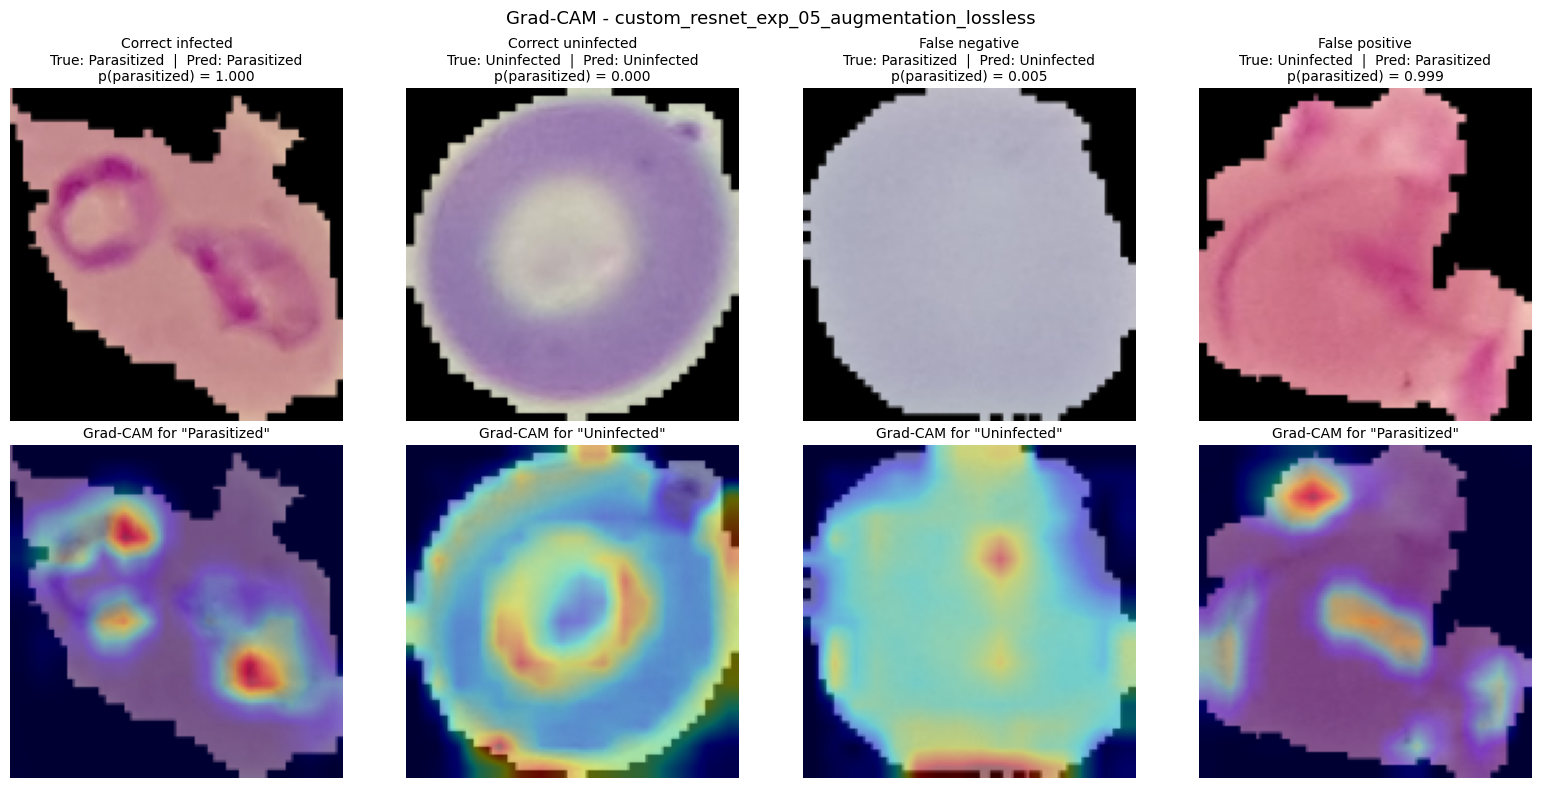

In [ ]:
if final_model is not None:
  show_grad_cam_cases(final_model, final_prob, FINAL_RUN)

**Grad-CAM interpretation:** For the correctly classified infected cell (p(parasitized) = 1.000), the heatmap focuses on two small, well-defined spots that match the dark-purple stained structures inside the cell: the ring-shaped body on the left and the dark clump on the right. These are the regions a microscopist would look at, because the stained chromatin of the parasite is what shows an infection, so in this case the model seems to rely on medically meaningful features. For the correctly classified uninfected cell, there is no parasite to point to, and the heatmap is spread over the whole cell, strongest on a ring around its pale centre. This suggests the model decides "uninfected" from the general appearance of a clean cell rather than from one specific region.

The incorrect predictions are more informative. For the false negative, the cell is pale and washed out, without any visible stained parasite, and the heatmap is broad and weak over the cell, so the model found nothing that looks like a parasite. This is the same pale, unusually coloured cell discussed in the error analysis, where the parasite is either too faint to detect or the image may be mislabeled. For the false positive (p = 0.999), the heatmap focuses on the darker pink folds and streaks of the cell, which shows that the model mistook staining artifacts with a similar colour for a parasite.

In two of the four examples (the correct uninfected cell and the false negative) part of the heat is also located on the black background at the bottom edge of the image. This could mean that the model partly uses the border or the shape of the cell as a shortcut, which is not medically meaningful, and it should be investigated further. Overall, the model mostly focuses on the cell and on stained structures, but it can be misled by stain colour, and it is very confident even when it is wrong.

Grad-CAM also has limits. The heatmaps come from the last feature map of 16×16 pixels, upsampled to 128×128, so they are coarse and cannot show the exact location of very small parasites. A heatmap only shows which regions influenced the prediction, not whether the reasoning is correct, so these results increase our confidence that the model often looks at the right structures, but they cannot prove that it has learned medically correct features.